**Phase 1: One-Shot Learning & Baseline Comparison**
* Implement Bandits and Baseline ML models.
* Perform baseline comparison using Linear Regression, Logistic Regression, and Decision Trees.
* Evaluate data quality: If the Bandit implementation yields proper F1 score plots, the generated data is considered sufficient.

**Phase 2: Step-wise Training**
* Implement Active Learning (AL) and Bandits (if possible).
* Generate plots based on the total number of fraud rules specifically for the AL component.


**Phase 3: Active Learning Implementation & Optimization**
* Implement XGBoost and Bandit-based Active Learning using the following strategies: Uncertainty, Cost-weighted, Expected cost reduction, and Diversity.
* If default loss functions are ineffective, implement and test custom loss functions.


**Phase 4: Validation & Visualization**
* Generate decreasing plots for financial costs and increasing plots for recall.
* Include validation plots within the Active Learning section.

## Setup

In [1]:
!git clone https://github.com/Nikshay-Jain/DDP.git /content/DDP

Cloning into '/content/DDP'...
remote: Enumerating objects: 97, done.
remote: Counting objects: 100% (24/24), done.
remote: Compressing objects: 100% (20/20), done.
remote: Total 97 (delta 8), reused 18 (delta 3), pack-reused 73 (from 1)
Receiving objects: 100% (97/97), 92.19 MiB | 49.61 MiB/s, done.
Resolving deltas: 100% (35/35), done.


In [2]:
import zipfile, os, shutil
import pandas as pd

zip_path = "/content/DDP/data_5L_new.zip"

extract_dir = "/content/extracted_zip"
with zipfile.ZipFile(zip_path, 'r') as z:
    z.extractall(extract_dir)

csv_file = None
for file in os.listdir(extract_dir):
    if file.endswith(".csv"):
        csv_file = os.path.join(extract_dir, file)
        break
if csv_file is None:
    raise FileNotFoundError("No CSV file found inside the ZIP.")

df = pd.read_csv(csv_file)
shutil.rmtree(extract_dir)
print("CSV loaded successfully!")

CSV loaded successfully!


In [3]:
df

,policy_no,policy_product,cust_occupation,tier,tier_premium_amt,occupants_count,paying_guest_no,business_use,unoccupied_days,unoccupied_reason,...,fire_safety_systems,security_systems,crime_rate,urban_rural,no_of_claims_5yr,premium_payment_behaviour,property_market_value,short_term_letting,fraud_probability,fraud_label
0,100000,Combined,skilled_worker,1,166.58,4,0,N,0,NaN,...,0,0,3,urban,0,74,880000,0,0.073655,0
1,100001,Combined,skilled_worker,2,342.37,2,0,N,0,NaN,...,1,1,1,rural,0,82,890000,0,0.066178,0
2,100002,Buildings,skilled_worker,2,325.97,1,0,N,30,NaN,...,0,0,3,urban,0,83,320000,0,0.087979,0
3,100003,Landlord,retired,1,160.16,6,0,N,0,NaN,...,0,1,5,urban,0,86,390000,0,0.062205,0
4,100004,Combined,professional,1,206.89,2,0,N,0,NaN,...,1,1,2,rural,0,71,590000,1,0.089477,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
499995,599995,Standard,white_collar,2,310.44,4,0,N,0,NaN,...,1,1,5,urban,0,84,610000,0,0.079920,0
499996,599996,Combined,retired,2,279.42,4,0,N,30,relocation,...,1,0,3,urban,2,92,300000,0,0.128952,0
499997,599997,Landlord,professional,2,336.84,4,0,N,0,NaN,...,0,1,1,urban,0,87,1060000,0,0.063849,0
499998,599998,Standard,white_collar,1,163.38,3,0,N,0,NaN,...,1,1,2,urban,1,76,390000,0,0.111040,0


## Baseline evaluation

In [20]:
import numpy as np
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier
from sklearn.metrics import precision_recall_fscore_support, roc_auc_score, precision_recall_curve, roc_curve, auc, confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings("ignore")
np.random.seed(42)


# -------------------------
# Cost helpers
# -------------------------
def calculate_costs(sum_insured, y_true, y_pred):
    s = np.asarray(sum_insured, dtype=float)
    y_true = np.asarray(y_true)
    y_pred = np.asarray(y_pred)
    costs = np.zeros(len(y_true), dtype=float)
    fn_mask = (y_true == 1) & (y_pred == 0)
    fp_mask = (y_true == 0) & (y_pred == 1)
    costs[fn_mask] = s[fn_mask] * 0.90
    costs[fp_mask] = 100.0
    return costs


def evaluate_cost_sensitive(y_true, y_pred, sum_insured, y_score=None):
    precision, recall, f1, _ = precision_recall_fscore_support(y_true, y_pred, average='binary', zero_division=0)
    try:
        rocauc = float(roc_auc_score(y_true, y_score if y_score is not None else y_pred))
    except Exception:
        rocauc = np.nan
    costs = calculate_costs(sum_insured, y_true, y_pred)
    fn_mask = (np.asarray(y_true) == 1) & (np.asarray(y_pred) == 0)
    fp_mask = (np.asarray(y_true) == 0) & (np.asarray(y_pred) == 1)
    return {
        'total_cost': float(costs.sum()),
        'fn_cost': float(costs[fn_mask].sum()),
        'fp_cost': float(costs[fp_mask].sum()),
        'fn_count': int(fn_mask.sum()),
        'fp_count': int(fp_mask.sum()),
        'tp': int(((np.asarray(y_true) == 1) & (np.asarray(y_pred) == 1)).sum()),
        'tn': int(((np.asarray(y_true) == 0) & (np.asarray(y_pred) == 0)).sum()),
        'precision': float(precision),
        'recall': float(recall),
        'f1': float(f1),
        'roc_auc': rocauc,
        'avg_cost_per_sample': float(costs.sum() / len(y_true))
    }


# -------------------------
# Stratified sampling utility
# -------------------------
def stratified_sample(df, label_col='fraud_label', n=20000, random_state=42):
    counts = df[label_col].value_counts().sort_index()
    total = counts.sum()
    if n >= total:
        return df.sample(frac=1.0, random_state=random_state).reset_index(drop=True)

    proportions = counts / total
    raw_alloc = proportions * n
    floor_alloc = np.floor(raw_alloc).astype(int)
    remainder = raw_alloc - floor_alloc
    allocated = floor_alloc.copy()
    remaining = int(n - floor_alloc.sum())
    if remaining > 0:
        idx_sort = np.argsort(-remainder.values)
        for i in range(remaining):
            allocated[idx_sort[i]] += 1
    parts = []
    for label, k in zip(counts.index, allocated):
        g = df[df[label_col] == label]
        parts.append(g.sample(n=min(k, len(g)), random_state=random_state) if len(g) > 0 else g)
    sampled = pd.concat(parts, ignore_index=True).sample(frac=1.0, random_state=random_state).reset_index(drop=True)
    return sampled

# -------------------------
# feature preparation (robust)
# -------------------------
def prepare_data(df, label_col='fraud_label', sum_col='sum_insured'):
    """Prepare features with robust fallback."""
    feature_template = [
        'tier', 'tier_premium_amt', 'occupants_count', 'paying_guest_no',
        'unoccupied_days', 'sum_insured', 'premium_with_tax',
        'risk_premium_with_credit_score', 'risk_premium_without_credit_score',
        'additional_coverage_amount', 'tier_limit_value', 'item_limit_value',
        'main_part_premium', 'accidental_damage_premium', 'outbuildings_premium',
        'APR_FLAG', 'previous_insurance_buildings', 'previous_insurance_cne',
        'property_eligibility', 'contents_claim_counts', 'building_claim_count',
        'flood_risk', 'storm_risk', 'other_natural_calamities_risk',
        'property_age', 'no_of_rooms', 'plumbing_elec_age',
        'smart_home', 'fire_safety_systems', 'security_systems',
        'crime_rate', 'no_of_claims_5yr', 'premium_payment_behaviour',
        'property_market_value', 'short_term_letting'
    ]
    categorical_template = ['cust_occupation', 'owner_details', 'property_type',
                           'construction_material', 'roof_material', 'urban_rural', 'policy_product']

    feature_cols = [c for c in feature_template if c in df.columns and c != label_col]
    categorical_cols = [c for c in categorical_template if c in df.columns]

    if not feature_cols:
        numeric_cols = df.select_dtypes(include=[np.number]).columns.tolist()
        feature_cols = [c for c in numeric_cols if c not in [label_col, sum_col]]

    df_enc = pd.get_dummies(df, columns=categorical_cols, drop_first=True)
    all_features = [c for c in df_enc.columns if (c in feature_cols) or any(cat in c for cat in categorical_cols)]

    if not all_features:
        all_features = [c for c in df_enc.select_dtypes(include=[np.number]).columns if c not in [label_col, sum_col]]

    X = df_enc[all_features].fillna(0).values
    y = df_enc[label_col].values
    sum_insured = df_enc[sum_col].values if sum_col in df_enc.columns else np.zeros(len(df_enc))

    return X, y, sum_insured, all_features

# -------------------------
# Cost-sensitive classifier wrapper (uses sample_weight and threshold tuning on validation)
# -------------------------
class CostSensitiveClassifier:
    def __init__(self, base_clf):
        self.clf = base_clf
        self.opt_threshold = 0.5

    def fit(self, X, y, sum_insured=None, X_val=None, y_val=None, sum_val=None, **fit_kwargs):
        # compute sample weights encoding cost: weight = y*(0.9*w) + (1-y)*100
        sample_weight = None
        if sum_insured is not None:
            s = np.asarray(sum_insured, dtype=float)
            sample_weight = (y * (0.9 * s)) + ((1 - y) * 100.0)
        try:
            if sample_weight is not None:
                self.clf.fit(X, y, sample_weight=sample_weight, **fit_kwargs)
            else:
                self.clf.fit(X, y, **fit_kwargs)
        except TypeError:
            # fallback if classifier doesn't support sample_weight argument
            self.clf.fit(X, y, **fit_kwargs)

        # threshold tuning on provided validation set (preferred)
        if X_val is not None and y_val is not None and sum_val is not None and hasattr(self.clf, "predict_proba"):
            proba = self.clf.predict_proba(X_val)[:, 1]
            thresholds = np.linspace(0.01, 0.99, 99)
            best_cost = np.inf
            best_t = 0.5
            for t in thresholds:
                y_pred = (proba >= t).astype(int)
                c = calculate_costs(sum_val, y_val, y_pred).sum()
                if c < best_cost:
                    best_cost = c
                    best_t = t
            self.opt_threshold = float(best_t)
        else:
            # fallback: tune on training set if validation not provided
            if sum_insured is not None and hasattr(self.clf, "predict_proba"):
                proba = self.clf.predict_proba(X)[:, 1]
                thresholds = np.linspace(0.01, 0.99, 99)
                best_cost = np.inf
                best_t = 0.5
                for t in thresholds:
                    y_pred = (proba >= t).astype(int)
                    c = calculate_costs(sum_insured, y, y_pred).sum()
                    if c < best_cost:
                        best_cost = c
                        best_t = t
                self.opt_threshold = float(best_t)
        return self

    def predict(self, X):
        if hasattr(self.clf, "predict_proba"):
            proba = self.clf.predict_proba(X)[:, 1]
            return (proba >= self.opt_threshold).astype(int)
        return self.clf.predict(X)

    def predict_proba(self, X):
        if hasattr(self.clf, "predict_proba"):
            return self.clf.predict_proba(X)
        if hasattr(self.clf, "decision_function"):
            s = self.clf.decision_function(X)
            p = 1 / (1 + np.exp(-s))
            return np.vstack([1 - p, p]).T
        preds = self.clf.predict(X)
        return np.vstack([1 - preds, preds]).T


# -------------------------
# Main compare function for ML baselines
# -------------------------
def compare_models(df, sample_size=20000, label_col='fraud_label', sum_col='sum_insured', random_state=42):
    df_s = stratified_sample(df, label_col=label_col, n=sample_size, random_state=random_state)
    X, y, sum_ins, feature_names = prepare_data(df_s, label_col=label_col, sum_col=sum_col)

    # train/val/test (70/15/15) stratified
    X_train, X_temp, y_train, y_temp, sum_train, sum_temp = train_test_split(
        X, y, sum_ins, test_size=0.30, random_state=random_state, stratify=y
    )
    X_val, X_test, y_val, y_test, sum_val, sum_test = train_test_split(
        X_temp, y_temp, sum_temp, test_size=0.50, random_state=random_state, stratify=y_temp
    )

    print("Shapes (train/val/test):", X_train.shape, X_val.shape, X_test.shape)
    print("Fraud positives (train/val/test):", y_train.sum(), y_val.sum(), y_test.sum())
    print("sum_insured stats (train): min,median,mean,max:",
          np.min(sum_train), np.median(sum_train), np.mean(sum_train), np.max(sum_train))

    scaler = StandardScaler()
    X_train_s = scaler.fit_transform(X_train)
    X_val_s = scaler.transform(X_val)
    X_test_s = scaler.transform(X_test)

    results = {}
    probs_store = {}

    models = {
        'Logistic Regression': LogisticRegression(max_iter=1000, class_weight=None, random_state=random_state),
        'Decision Tree': DecisionTreeClassifier(max_depth=10, min_samples_split=50, min_samples_leaf=20,
                                                class_weight=None, random_state=random_state),
        'Random Forest': RandomForestClassifier(n_estimators=100, max_depth=10, min_samples_split=50,
                                               class_weight=None, random_state=random_state),
        'XGBoost': XGBClassifier(n_estimators=200, max_depth=6, learning_rate=0.05,
                                 use_label_encoder=False, eval_metric='logloss', random_state=random_state)
    }

    for name, base_clf in models.items():
        print("Training", name)
        cs = CostSensitiveClassifier(base_clf).fit(X_train_s, y_train, sum_insured=sum_train,
                                                   X_val=X_val_s, y_val=y_val, sum_val=sum_val)
        y_pred = cs.predict(X_test_s)
        y_proba = cs.predict_proba(X_test_s)[:, 1]
        r = evaluate_cost_sensitive(y_test, y_pred, sum_test, y_score=y_proba)
        r['proba'] = y_proba
        results[name] = r
        probs_store[name] = (y_test, y_proba)

    # explicit DataFrame construction
    rows = []
    for m, r in results.items():
        rows.append({
            'Model': m,
            'Total Cost (£)': float(r['total_cost']),
            'FN Cost (£)': float(r['fn_cost']),
            'FP Cost (£)': float(r['fp_cost']),
            'FN Count': int(r['fn_count']),
            'FP Count': int(r['fp_count']),
            'TP': int(r['tp']),
            'TN': int(r['tn']),
            'Precision': float(r['precision']),
            'Recall': float(r['recall']),
            'F1': float(r['f1']),
            'ROC AUC': float(r['roc_auc']) if r['roc_auc'] is not None else np.nan,
            'Avg Cost/Sample (£)': float(r['avg_cost_per_sample'])
        })
    comp = pd.DataFrame(rows).sort_values('Total Cost (£)').reset_index(drop=True)
    print(comp.to_string(index=False))

    # Visualizations (cost+metrics + PR/ROC)
    plt.figure(figsize=(14, 10))
    # total cost
    plt.subplot(2, 2, 1)
    models_list = comp['Model']
    costs = comp['Total Cost (£)']
    colors = ['#2ecc71' if c == costs.min() else '#e74c3c' if c == costs.max() else '#3498db' for c in costs]
    plt.barh(models_list, costs, color=colors)
    plt.gca().invert_yaxis()
    plt.title('Total Cost Comparison')
    for i, v in enumerate(costs): plt.text(v, i, f' £{v:,.0f}', va='center')

    # cost breakdown
    plt.subplot(2, 2, 2)
    x = np.arange(len(models_list)); width = 0.35
    plt.bar(x - width/2, comp['FN Cost (£)'], width, label='FN Cost')
    plt.bar(x + width/2, comp['FP Cost (£)'], width, label='FP Cost')
    plt.xticks(x, models_list, rotation=45)
    plt.legend()
    plt.title('Cost Breakdown')

    # PR scatter
    plt.subplot(2, 2, 3)
    sc = plt.scatter(comp['Recall'], comp['Precision'], s=150, c=comp['Total Cost (£)'], cmap='RdYlGn_r', edgecolors='k')
    for i, m in enumerate(models_list): plt.annotate(m, (comp['Recall'].iloc[i], comp['Precision'].iloc[i]), xytext=(6,4), textcoords='offset points')
    plt.colorbar(sc, label='Total Cost (£)'); plt.xlabel('Recall'); plt.ylabel('Precision')

    # error counts
    plt.subplot(2, 2, 4)
    plt.bar(x - width/2, comp['FN Count'], width, label='FN')
    plt.bar(x + width/2, comp['FP Count'], width, label='FP')
    plt.xticks(x, models_list, rotation=45)
    plt.legend()
    plt.title('Error Counts')

    plt.tight_layout()
    plt.show()

    # PR & ROC curves
    plt.figure(figsize=(12, 5))
    plt.subplot(1, 2, 1)
    for m, (y_t, y_p) in probs_store.items():
        try:
            p, r, _ = precision_recall_curve(y_t, y_p)
            plt.plot(r, p, label=f"{m} (F1={results[m]['f1']:.3f})")
        except Exception:
            continue
    plt.xlabel('Recall'); plt.ylabel('Precision'); plt.title('Precision-Recall Curves'); plt.legend(); plt.grid(alpha=0.2)

    plt.subplot(1, 2, 2)
    for m, (y_t, y_p) in probs_store.items():
        try:
            fpr, tpr, _ = roc_curve(y_t, y_p)
            roc_auc = auc(fpr, tpr)
            plt.plot(fpr, tpr, label=f"{m} (AUC={roc_auc:.3f})")
        except Exception:
            continue
    plt.plot([0, 1], [0, 1], 'k--', lw=0.8)
    plt.xlabel('FPR'); plt.ylabel('TPR'); plt.title('ROC Curves'); plt.legend(); plt.grid(alpha=0.2)
    plt.tight_layout()
    plt.show()

    return results, comp

Shapes (train/val/test): (35000, 59) (7500, 59) (7500, 59)
Fraud positives (train/val/test): 1760 377 377
sum_insured stats (train): min,median,mean,max: 100000 350000.0 381967.14285714284 850000
Training Logistic Regression
Training Decision Tree
Training Random Forest
Training XGBoost
              Model  Total Cost (£)  FN Cost (£)  FP Cost (£)  FN Count  FP Count  TP   TN  Precision   Recall       F1  ROC AUC  Avg Cost/Sample (£)
Logistic Regression        375500.0     360000.0      15500.0         2       155 375 6968   0.707547 0.994695 0.826902 0.997887            50.066667
      Random Forest        700900.0          0.0     700900.0         0      7009 377  114   0.051043 1.000000 0.097127 0.973736            93.453333
      Decision Tree       1634600.0    1620000.0      14600.0         5       146 372 6977   0.718147 0.986737 0.831285 0.991614           217.946667
            XGBoost       3075900.0    3060000.0      15900.0         7       159 370 6964   0.699433 0.981432 0

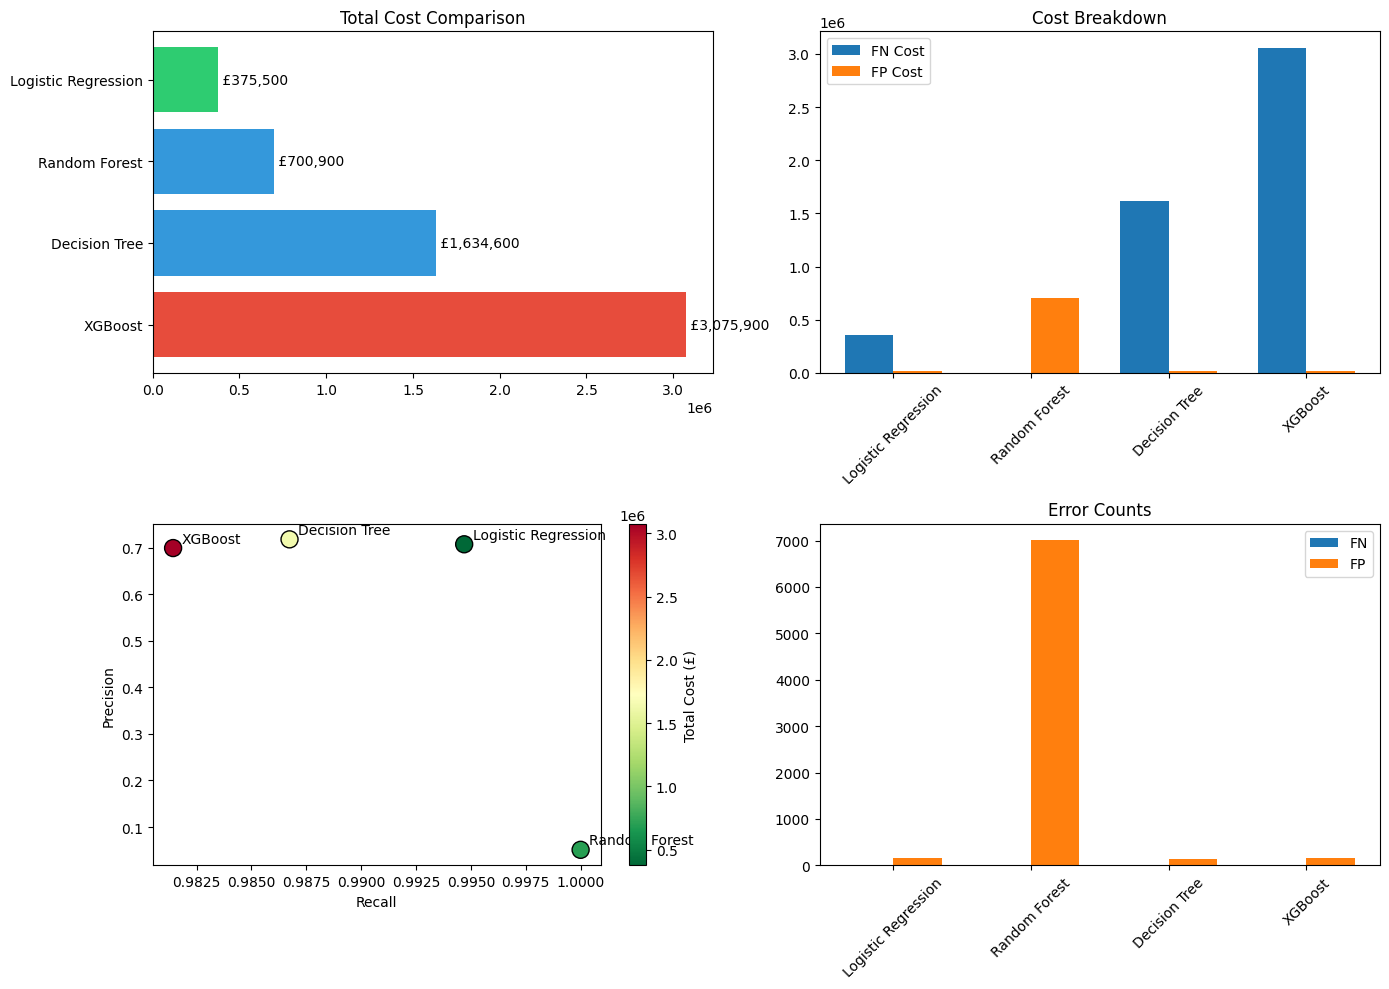

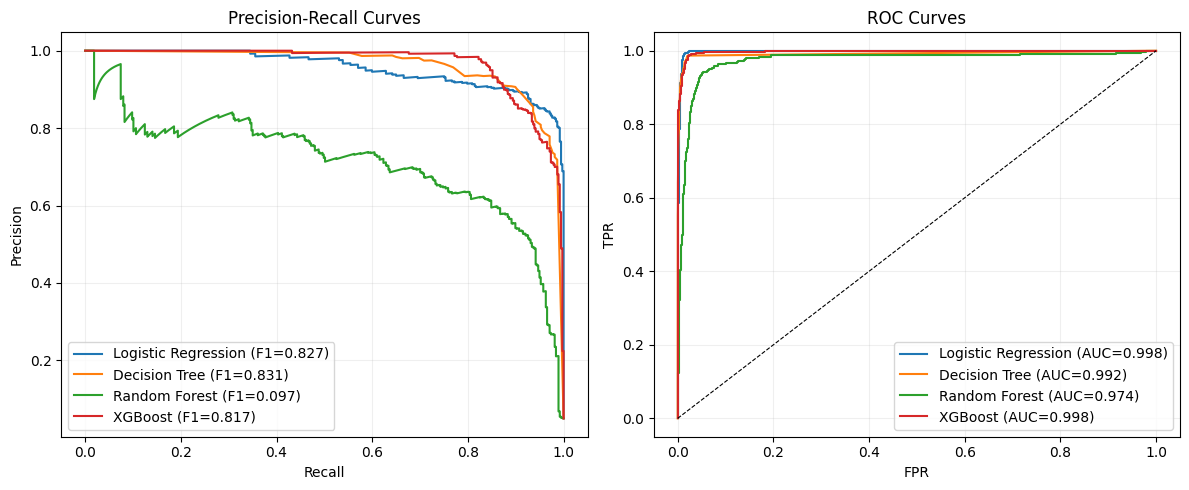

In [21]:
results_ml, comparison_ml = compare_models(df, sample_size=50000)

## RL algos

In [22]:
import numpy as np
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from scipy.optimize import minimize
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings("ignore")
np.random.seed(42)

# -------------------------
# Defaults for unified cost model
# -------------------------
FP_COST_DEFAULT = 100.0        # default false-positive cost (can be overridden)
FN_MULTIPLIER_DEFAULT = 0.9    # FN cost = FN_MULTIPLIER * sum_insured

# -------------------------
# Cost helpers (shared convention)
# -------------------------
def calculate_costs(sum_insured, y_true, y_pred, fp_cost=FP_COST_DEFAULT, fn_multiplier=FN_MULTIPLIER_DEFAULT):
    """
    Vectorized cost:
      FN = fn_multiplier * sum_insured
      FP = fp_cost
      TP/TN = 0
    """
    s = np.asarray(sum_insured, dtype=float)
    y_true = np.asarray(y_true)
    y_pred = np.asarray(y_pred)
    costs = np.zeros(len(y_true), dtype=float)
    fn_mask = (y_true == 1) & (y_pred == 0)
    fp_mask = (y_true == 0) & (y_pred == 1)
    costs[fn_mask] = s[fn_mask] * float(fn_multiplier)
    costs[fp_mask] = float(fp_cost)
    return costs


def evaluate_cost_sensitive(y_true, y_pred, sum_insured, y_score=None,
                            fp_cost=FP_COST_DEFAULT, fn_multiplier=FN_MULTIPLIER_DEFAULT):
    """
    Returns a dict of cost metrics and classification metrics.
    Uses the unified cost parameters.
    """
    costs = calculate_costs(sum_insured, y_true, y_pred, fp_cost=fp_cost, fn_multiplier=fn_multiplier)
    fn_mask = (np.asarray(y_true) == 1) & (np.asarray(y_pred) == 0)
    fp_mask = (np.asarray(y_true) == 0) & (np.asarray(y_pred) == 1)

    from sklearn.metrics import precision_recall_fscore_support, roc_auc_score
    precision, recall, f1, _ = precision_recall_fscore_support(y_true, y_pred, average='binary', zero_division=0)
    try:
        rocauc = float(roc_auc_score(y_true, y_score if y_score is not None else y_pred))
    except Exception:
        rocauc = np.nan

    return {
        'total_cost': float(costs.sum()),
        'fn_cost': float(costs[fn_mask].sum()),
        'fp_cost': float(costs[fp_mask].sum()),
        'fn_count': int(fn_mask.sum()),
        'fp_count': int(fp_mask.sum()),
        'tp': int(((np.asarray(y_true) == 1) & (np.asarray(y_pred) == 1)).sum()),
        'tn': int(((np.asarray(y_true) == 0) & (np.asarray(y_pred) == 0)).sum()),
        'precision': float(precision),
        'recall': float(recall),
        'f1': float(f1),
        'roc_auc': rocauc,
        'avg_cost_per_sample': float(costs.sum() / len(y_true))
    }


# -------------------------
# Stratified sampling utility
# -------------------------
def stratified_sample(df, label_col='fraud_label', n=20000, random_state=42):
    """
    Large-remainder proportional stratified sampling; if n >= len(df) returns shuffled df.
    """
    counts = df[label_col].value_counts().sort_index()
    total = counts.sum()
    if n >= total:
        return df.sample(frac=1.0, random_state=random_state).reset_index(drop=True)

    proportions = counts / total
    raw_alloc = proportions * n
    floor_alloc = np.floor(raw_alloc).astype(int)
    remainder = raw_alloc - floor_alloc
    allocated = floor_alloc.copy()
    remaining = int(n - floor_alloc.sum())
    if remaining > 0:
        idx_sort = np.argsort(-remainder.values)
        for i in range(remaining):
            allocated[idx_sort[i]] += 1

    parts = []
    for label, k in zip(counts.index, allocated):
        g = df[df[label_col] == label]
        parts.append(g.sample(n=min(k, len(g)), random_state=random_state) if len(g) > 0 else g)
    sampled = pd.concat(parts, ignore_index=True).sample(frac=1.0, random_state=random_state).reset_index(drop=True)
    return sampled


# -------------------------
# IDCSPA: Instance-Dependent Cost-Sensitive Passive-Aggressive
# -------------------------
class IDCSPA:
    def __init__(self, C=1.0, fp_cost=FP_COST_DEFAULT, fn_multiplier=FN_MULTIPLIER_DEFAULT):
        self.C = float(C)
        self.theta = None
        self.fp_cost = float(fp_cost)
        self.fn_multiplier = float(fn_multiplier)

    def fit(self, X, y, sum_insured, epochs=3):
        """
        Online updates. y in {0,1} internally; uses unified cost model.
        """
        n, d = X.shape
        self.theta = np.zeros(d, dtype=float)
        y_signed = (2 * np.asarray(y).astype(int)) - 1

        for epoch in range(epochs):
            idx = np.random.permutation(n)
            for i in idx:
                x_i = X[i]
                y_i = y_signed[i]
                w_i = float(sum_insured[i])

                y_pred_raw = np.sign(self.theta.dot(x_i))
                if y_pred_raw == 0:
                    y_pred_raw = -1

                # use unified costs
                if y_pred_raw == -1 and y_i == 1:   # FN
                    loss = w_i * self.fn_multiplier
                elif y_pred_raw == 1 and y_i == -1:  # FP
                    loss = self.fp_cost
                else:
                    loss = 0.0

                if loss > 0:
                    numerator = (y_pred_raw - y_i) * (self.theta.dot(x_i)) + np.sqrt(loss)
                    denom = np.linalg.norm((y_pred_raw - y_i) * x_i) ** 2
                    if denom <= 0:
                        continue
                    tau = min(self.C, max(0.0, numerator / denom))
                    self.theta += tau * (y_i - y_pred_raw) * x_i
        return self

    def predict(self, X):
        preds = np.sign(X.dot(self.theta))
        preds[preds == 0] = -1
        return ((preds + 1) / 2).astype(int)

    def decision_function(self, X):
        return X.dot(self.theta)


# -------------------------
# CSLB: Cost-Sensitive Logistic Bandit (cost-aligned surrogate objective)
# -------------------------
class CSLB:
    def __init__(self, alpha=1.0, lam=1e-3, maxiter=200,
                 fp_cost=FP_COST_DEFAULT, fn_multiplier=FN_MULTIPLIER_DEFAULT):
        """
        alpha: prior scaling for initial covariance
        lam: L2 regularization
        maxiter: L-BFGS max iterations
        fp_cost, fn_multiplier: unified cost parameters
        """
        self.alpha = float(alpha)
        self.lam = float(lam)
        self.maxiter = int(maxiter)
        self.theta_mean = None
        self.theta_cov = None
        self.fp_cost = float(fp_cost)
        self.fn_multiplier = float(fn_multiplier)

    def _sigmoid(self, z):
        return 1.0 / (1.0 + np.exp(-np.clip(z, -500, 500)))

    def _compute_threshold(self, sum_insured):
        """
        Per-instance decision threshold consistent with evaluation:
          h(w) = FP / (FP + FN)
        """
        w = float(sum_insured)
        FP = float(self.fp_cost)
        FN = float(self.fn_multiplier) * w
        denom = FP + FN
        if denom <= 0:
            return 0.5
        return float(np.clip(FP / denom, 0.0, 1.0))

    def _obj_and_grad(self, theta, X, y, sum_ins_scaled):
        """
        Minimize average expected cost of a stochastic policy that flags with prob p=sigma(X theta).
        Per-sample expected cost:
            E[cost] = y*(1-p)*FN + (1-y)*p*FP
        This is differentiable and aligns training with evaluation.
        Returns (obj, grad)
        """
        n = X.shape[0]
        z = X.dot(theta)
        p = self._sigmoid(z)  # (n,)

        # recover true FN and FP per (scaled) sums; note we used scaled sums for optimization
        # the actual FN scale will be accounted by scaling factor (handled when building sum_ins_scaled)
        FN_vec = self.fn_multiplier * sum_ins_scaled  # per-sample FN (scaled)
        FP = self.fp_cost  # scalar

        # average expected cost
        cost_vec = y * (1 - p) * FN_vec + (1 - y) * p * FP
        obj = float(cost_vec.mean() + 0.5 * self.lam * np.dot(theta, theta))

        # gradient: for sample i, d/dtheta = p*(1-p)*x_i * ( - y_i * FN_i + (1 - y_i) * FP )
        coeff = ( - y * FN_vec + (1 - y) * FP ) * (p * (1 - p))  # (n,)
        grad = (X.T.dot(coeff) / max(1, n)) + self.lam * theta

        return obj, grad

    def fit(self, X, y, sum_insured):
        """
        Fit by optimizing the differentiable expected-cost surrogate.
        We scale sum_insured internally for numeric stability.
        """
        X = np.asarray(X)
        y = np.asarray(y).astype(int)
        n, d = X.shape

        if self.theta_mean is None:
            self.theta_mean = np.zeros(d, dtype=float)
            self.theta_cov = np.eye(d) * self.alpha

        # scale sums for optimization
        scale = (np.mean(sum_insured) + 1e-9)
        sum_scaled = np.asarray(sum_insured, dtype=float) / scale

        def fun(theta):
            return self._obj_and_grad(theta, X, y, sum_scaled)

        res = minimize(fun, self.theta_mean, method='L-BFGS-B', jac=True,
                       options={'maxiter': self.maxiter, 'disp': False})

        # accept best found solution
        self.theta_mean = res.x

        # Hessian (Laplace approx) compute with regularization
        eps = 1e-6
        z = X.dot(self.theta_mean)
        p = self._sigmoid(z)
        W = p * (1 - p)
        X_weighted = X * W[:, None]
        H = (X.T.dot(X_weighted) / max(1, n)) + (eps + self.lam) * np.eye(d)

        try:
            self.theta_cov = np.linalg.inv(H)
        except np.linalg.LinAlgError:
            self.theta_cov = np.linalg.pinv(H)

        return self

    def predict(self, X, sum_insured):
        """
        Thompson sampling: sample one theta from posterior, then apply per-instance threshold h(w).
        """
        if self.theta_mean is None:
            raise ValueError("CSLB not fitted")

        try:
            theta_sample = np.random.multivariate_normal(self.theta_mean, self.theta_cov)
        except Exception:
            theta_sample = self.theta_mean.copy()

        p = self._sigmoid(X.dot(theta_sample))
        thresholds = np.array([self._compute_threshold(w) for w in np.atleast_1d(sum_insured)])
        return (p >= thresholds).astype(int)

    def predict_proba(self, X):
        if self.theta_mean is None:
            raise ValueError("CSLB not fitted")
        probs = self._sigmoid(X.dot(self.theta_mean))
        return np.vstack([1 - probs, probs]).T


# -------------------------
# Compare RL algorithms (IDCSPA vs CSLB) - now cost-aligned
# -------------------------
def compare_rl_algorithms(df, sample_size=20000, label_col='fraud_label', sum_col='sum_insured',
                          random_state=42, fp_cost=FP_COST_DEFAULT, fn_multiplier=FN_MULTIPLIER_DEFAULT):
    """
    Stratified sample -> stratified train/val/test (70/15/15) -> train IDCSPA and CSLB -> evaluate on test.
    fp_cost and fn_multiplier override defaults and are passed through to models & evaluation.
    """
    # stratified sample
    df_s = stratified_sample(df, label_col=label_col, n=sample_size, random_state=random_state)

    # numeric feature selection (use numeric columns)
    numeric_cols = df_s.select_dtypes(include=[np.number]).columns.tolist()
    feature_cols = [c for c in numeric_cols if c not in [label_col, sum_col]]
    if len(feature_cols) == 0:
        raise ValueError("No numeric features found in df sample. Provide numeric feature columns.")

    X_all = df_s[feature_cols].fillna(0).values
    y_all = df_s[label_col].values.astype(int)
    sum_all = df_s[sum_col].values.astype(float) if sum_col in df_s.columns else np.ones(len(df_s)) * 1000.0

    # train/val/test stratified (70/15/15)
    X_train, X_temp, y_train, y_temp, sum_train, sum_temp = train_test_split(
        X_all, y_all, sum_all, test_size=0.30, random_state=random_state, stratify=y_all
    )
    X_val, X_test, y_val, y_test, sum_val, sum_test = train_test_split(
        X_temp, y_temp, sum_temp, test_size=0.50, random_state=random_state, stratify=y_temp
    )

    # diagnostics
    print("Shapes (train/val/test):", X_train.shape, X_val.shape, X_test.shape)
    print("Fraud positives (train/val/test):", y_train.sum(), y_val.sum(), y_test.sum())
    print("sum_insured stats (train): min,median,mean,max:",
          np.min(sum_train), np.median(sum_train), np.mean(sum_train), np.max(sum_train))

    # standardize features
    scaler = StandardScaler()
    X_train_s = scaler.fit_transform(X_train)
    X_val_s = scaler.transform(X_val)
    X_test_s = scaler.transform(X_test)

    results = {}
    probs_store = {}

    # 1) IDCSPA (use unified cost)
    print("Training IDCSPA...")
    idcspa = IDCSPA(C=1.0, fp_cost=fp_cost, fn_multiplier=fn_multiplier).fit(X_train_s, y_train, sum_train, epochs=3)
    y_pred_idcspa = idcspa.predict(X_test_s)
    probs_idcspa = idcspa.decision_function(X_test_s)
    probs_idcspa = 1 / (1 + np.exp(-probs_idcspa))
    results['IDCSPA'] = evaluate_cost_sensitive(y_test, y_pred_idcspa, sum_test, y_score=probs_idcspa,
                                               fp_cost=fp_cost, fn_multiplier=fn_multiplier)
    results['IDCSPA']['proba'] = probs_idcspa
    probs_store['IDCSPA'] = (y_test, probs_idcspa)

    # 2) CSLB (surrogate expected-cost objective + Thompson sampling + unified cost)
    print("Training CSLB...")
    cslb = CSLB(alpha=1.0, lam=1e-3, maxiter=200, fp_cost=fp_cost, fn_multiplier=fn_multiplier).fit(
        X_train_s, y_train, sum_train)
    y_pred_cslb = cslb.predict(X_test_s, sum_test)
    probs_cslb = cslb.predict_proba(X_test_s)[:, 1]
    results['CSLB'] = evaluate_cost_sensitive(y_test, y_pred_cslb, sum_test, y_score=probs_cslb,
                                              fp_cost=fp_cost, fn_multiplier=fn_multiplier)
    results['CSLB']['proba'] = probs_cslb
    probs_store['CSLB'] = (y_test, probs_cslb)

    # build comparison DataFrame explicitly
    rows = []
    for m, r in results.items():
        rows.append({
            'Model': m,
            'Total Cost (£)': float(r['total_cost']),
            'FN Cost (£)': float(r['fn_cost']),
            'FP Cost (£)': float(r['fp_cost']),
            'FN Count': int(r['fn_count']),
            'FP Count': int(r['fp_count']),
            'TP': int(r['tp']),
            'TN': int(r['tn']),
            'Precision': float(r['precision']),
            'Recall': float(r['recall']),
            'F1': float(r['f1']),
            'ROC AUC': float(r['roc_auc']) if r['roc_auc'] is not None else np.nan,
            'Avg Cost/Sample (£)': float(r['avg_cost_per_sample'])
        })
    comp = pd.DataFrame(rows).sort_values('Total Cost (£)').reset_index(drop=True)
    print(comp.to_string(index=False))

    # quick plots (cost bar and metrics)
    plt.figure(figsize=(12, 4))
    plt.subplot(1, 2, 1)
    models = comp['Model']
    costs = comp['Total Cost (£)']
    colors = ['#2ecc71' if c == costs.min() else '#e74c3c' if c == costs.max() else '#3498db' for c in costs]
    plt.barh(models, costs, color=colors)
    plt.gca().invert_yaxis()
    plt.title('RL Algorithms: Total Cost Comparison')
    for i, v in enumerate(costs): plt.text(v, i, f' £{v:,.0f}', va='center')

    plt.subplot(1, 2, 2)
    x = np.arange(len(models))
    width = 0.25
    plt.bar(x - width, comp['Precision'], width, label='Precision')
    plt.bar(x, comp['Recall'], width, label='Recall')
    plt.bar(x + width, comp['F1'], width, label='F1')
    plt.xticks(x, models, rotation=45)
    plt.ylim(0, 1)
    plt.legend()
    plt.title('RL Algorithms: Performance Metrics')
    plt.tight_layout()
    plt.show()

    return results, comp

Shapes (train/val/test): (35000, 39) (7500, 39) (7500, 39)
Fraud positives (train/val/test): 1760 377 377
sum_insured stats (train): min,median,mean,max: 100000.0 350000.0 381967.14285714284 850000.0
Training IDCSPA...
Training CSLB...
 Model  Total Cost (£)  FN Cost (£)  FP Cost (£)  FN Count  FP Count  TP   TN  Precision   Recall       F1  ROC AUC  Avg Cost/Sample (£)
IDCSPA         98500.0          0.0      98500.0         0       985 377 6138   0.276799 1.000000 0.433583 0.999111            13.133333
  CSLB      55772600.0   55395000.0     377600.0       161      3776 216 3347   0.054108 0.572944 0.098878 0.915875          7436.346667


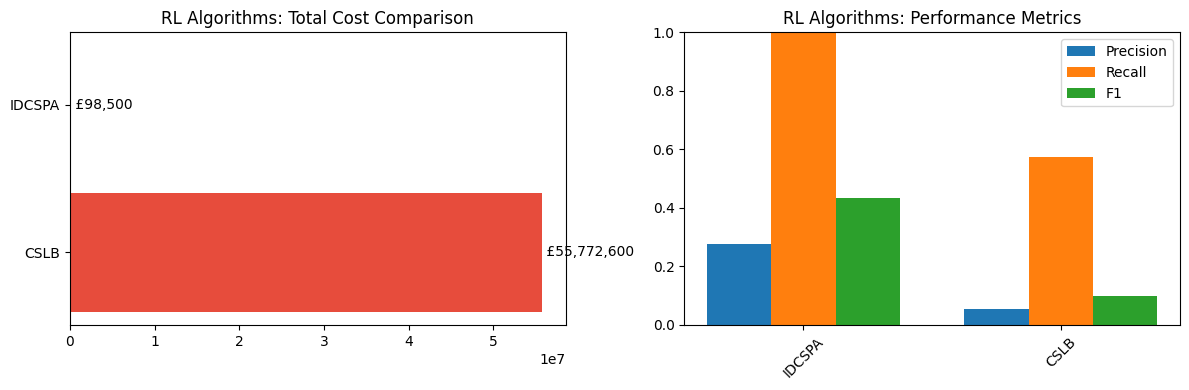

In [23]:
results_rl, comparison_rl = compare_rl_algorithms(df, sample_size=50000)

In [24]:
# Combined comparison
combined = pd.concat([comparison_ml, comparison_rl]).sort_values('Total Cost (£)').reset_index(drop=True)
combined

,Model,Total Cost (£),FN Cost (£),FP Cost (£),FN Count,FP Count,TP,TN,Precision,Recall,F1,ROC AUC,Avg Cost/Sample (£)
0,IDCSPA,98500.0,0.0,98500.0,0,985,377,6138,0.276799,1.000000,0.433583,0.999111,13.133333
1,Logistic Regression,375500.0,360000.0,15500.0,2,155,375,6968,0.707547,0.994695,0.826902,0.997887,50.066667
2,Random Forest,700900.0,0.0,700900.0,0,7009,377,114,0.051043,1.000000,0.097127,0.973736,93.453333
3,Decision Tree,1634600.0,1620000.0,14600.0,5,146,372,6977,0.718147,0.986737,0.831285,0.991614,217.946667
4,XGBoost,3075900.0,3060000.0,15900.0,7,159,370,6964,0.699433,0.981432,0.816777,0.997576,410.120000
5,CSLB,55772600.0,55395000.0,377600.0,161,3776,216,3347,0.054108,0.572944,0.098878,0.915875,7436.346667


## Active learning starts

In [36]:
import numpy as np
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from xgboost import XGBClassifier
from sklearn.cluster import MiniBatchKMeans
from sklearn.metrics import confusion_matrix, precision_recall_fscore_support, roc_auc_score
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings("ignore")
np.random.seed(42)

# ==================== SHARED FUNCTIONS (SAME AS BASELINE) ====================
def calculate_costs(sum_insured, y_true, y_pred):
    """FN: 90% of sum_insured, FP: £100"""
    sum_insured = np.asarray(sum_insured)
    y_true, y_pred = np.asarray(y_true), np.asarray(y_pred)
    costs = np.zeros(len(y_true), dtype=float)

    fn_mask = (y_true == 1) & (y_pred == 0)
    fp_mask = (y_true == 0) & (y_pred == 1)

    costs[fn_mask] = sum_insured[fn_mask] * 0.90
    costs[fp_mask] = 100.0
    return costs

def evaluate_cost_sensitive(y_true, y_pred, sum_insured):
    """Comprehensive evaluation matching baseline"""
    costs = calculate_costs(sum_insured, y_true, y_pred)
    fn_mask = (y_true == 1) & (y_pred == 0)
    fp_mask = (y_true == 0) & (y_pred == 1)

    precision, recall, f1, _ = precision_recall_fscore_support(y_true, y_pred, average='binary', zero_division=0)
    try:
        rocauc = roc_auc_score(y_true, y_pred)
    except:
        rocauc = np.nan

    return {
        'total_cost': float(costs.sum()),
        'fn_cost': float(costs[fn_mask].sum()),
        'fp_cost': float(costs[fp_mask].sum()),
        'fn_count': int(fn_mask.sum()),
        'fp_count': int(fp_mask.sum()),
        'tp': int(((y_true == 1) & (y_pred == 1)).sum()),
        'tn': int(((y_true == 0) & (y_pred == 0)).sum()),
        'precision': float(precision),
        'recall': float(recall),
        'f1': float(f1),
        'roc_auc': float(rocauc)
    }

def prepare_data(df, label_col='fraud_label', sum_col='sum_insured'):
    """Feature preparation matching baseline"""
    feature_template = [
        'tier', 'tier_premium_amt', 'occupants_count', 'paying_guest_no',
        'unoccupied_days', 'sum_insured', 'premium_with_tax',
        'risk_premium_with_credit_score', 'risk_premium_without_credit_score',
        'additional_coverage_amount', 'tier_limit_value', 'item_limit_value',
        'main_part_premium', 'accidental_damage_premium', 'outbuildings_premium',
        'APR_FLAG', 'previous_insurance_buildings', 'previous_insurance_cne',
        'property_eligibility', 'contents_claim_counts', 'building_claim_count',
        'flood_risk', 'storm_risk', 'other_natural_calamities_risk',
        'property_age', 'no_of_rooms', 'plumbing_elec_age',
        'smart_home', 'fire_safety_systems', 'security_systems',
        'crime_rate', 'no_of_claims_5yr', 'premium_payment_behaviour',
        'property_market_value', 'short_term_letting'
    ]
    categorical_template = ['cust_occupation', 'owner_details', 'property_type',
                           'construction_material', 'roof_material', 'urban_rural', 'policy_product']

    feature_cols = [c for c in feature_template if c in df.columns and c != label_col]
    categorical_cols = [c for c in categorical_template if c in df.columns]

    if not feature_cols:
        numeric_cols = df.select_dtypes(include=[np.number]).columns.tolist()
        feature_cols = [c for c in numeric_cols if c not in [label_col, sum_col]]

    df_enc = pd.get_dummies(df, columns=categorical_cols, drop_first=True)
    all_features = [c for c in df_enc.columns if (c in feature_cols) or any(cat in c for cat in categorical_cols)]

    if not all_features:
        all_features = [c for c in df_enc.select_dtypes(include=[np.number]).columns if c not in [label_col, sum_col]]

    X = df_enc[all_features].fillna(0).values
    y = df_enc[label_col].values
    sum_insured = df_enc[sum_col].values if sum_col in df_enc.columns else np.zeros(len(df_enc))

    return X, y, sum_insured, all_features

def find_optimal_threshold(model, X, y, sum_insured):
    """Find cost-minimizing threshold"""
    proba = model.predict_proba(X)[:, 1]
    thresholds = np.linspace(0.05, 0.95, 50)
    best_cost = np.inf
    best_t = 0.5

    for t in thresholds:
        y_pred = (proba >= t).astype(int)
        cost = calculate_costs(sum_insured, y, y_pred).sum()
        if cost < best_cost:
            best_cost = cost
            best_t = t

    return best_t

# ==================== RULE-BASED INITIALIZATION ====================
def apply_fraud_rules(df):
    """Industry-standard fraud rules for initial seeding"""
    flags = pd.Series(False, index=df.index)

    claim_ratio = df['sum_insured'] / (df['premium_with_tax'] + 1)

    # Rule 1: High claim ratio + no previous insurance + claims
    flags |= (claim_ratio > 1500) & (df['previous_insurance_buildings'] == 0) & (df['no_of_claims_5yr'] > 0)

    # Rule 2: Accidental damage + unoccupied + claims
    flags |= (df['accidental_damage_premium'] > 0) & (df['unoccupied_days'] >= 30) & (df['no_of_claims_5yr'] > 0)

    # Rule 3: High claim frequency
    flags |= (df['no_of_claims_5yr'] >= 3)

    return flags

# ==================== ACTIVE LEARNING AGENT ====================
class ActiveLearner:
    def __init__(self, strategy='uncertainty'):
        self.strategy = strategy
        self.model = None
        self.scaler = StandardScaler()
        self.threshold = 0.5
        self.labeled_X = None
        self.labeled_y = None
        self.labeled_sum = None

    def initialize(self, X_init, y_init, sum_init):
        """Initialize with rule-based flagged cases"""
        self.labeled_X = self.scaler.fit_transform(X_init)
        self.labeled_y = y_init.copy()
        self.labeled_sum = sum_init.copy()
        self._train()

    def _train(self):
        """Train XGBoost with cost-aware weighting"""
        # Cost-aware sample weights
        weights = np.zeros(len(self.labeled_y))
        weights[self.labeled_y == 1] = self.labeled_sum[self.labeled_y == 1] * 0.9  # FN cost
        weights[self.labeled_y == 0] = 100  # FP cost
        weights = weights / weights.mean()  # Normalize

        pos_weight = (self.labeled_y == 0).sum() / max(1, (self.labeled_y == 1).sum())

        self.model = XGBClassifier(
            n_estimators=100, max_depth=6, learning_rate=0.1,
            scale_pos_weight=pos_weight, random_state=42,
            eval_metric='logloss', n_jobs=-1
        )

        # self.model = XGBClassifier(n_estimators=200, max_depth=6, learning_rate=0.05, scale_pos_weight=pos_weight,
        #                          use_label_encoder=False, eval_metric='logloss', random_state=42, n_jobs=-1)

        # self.model = LogisticRegression(max_iter=1000, class_weight=None, random_state=42)

        self.model.fit(self.labeled_X, self.labeled_y, sample_weight=weights)
        self.threshold = find_optimal_threshold(self.model, self.labeled_X, self.labeled_y, self.labeled_sum)

    def query(self, X_pool, sum_pool, budget):
        """Select most informative samples based on strategy"""
        X_scaled = self.scaler.transform(X_pool)
        proba = self.model.predict_proba(X_scaled)[:, 1]

        if self.strategy == 'uncertainty':
            # Least confidence: samples closest to 0.5
            scores = np.abs(proba - 0.5)
            indices = np.argsort(scores)[:budget]

        elif self.strategy == 'cost_weighted':
            # Uncertainty weighted by potential cost
            uncertainty = 0.5 - np.abs(proba - 0.5)
            norm_cost = sum_pool / (sum_pool.max() + 1)
            scores = uncertainty * norm_cost
            indices = np.argsort(-scores)[:budget]

        elif self.strategy == 'expected_cost_reduction':
            # Expected risk if we keep current decision
            risk_if_0 = proba * (sum_pool * 0.9)  # Miss fraud
            risk_if_1 = (1 - proba) * 100  # False alarm
            current_risk = np.where(proba < self.threshold, risk_if_0, risk_if_1)
            indices = np.argsort(-current_risk)[:budget]

        elif self.strategy == 'diversity':
            # K-means clustering for diverse samples
            n_clusters = min(budget, len(X_scaled) // 2)
            kmeans = MiniBatchKMeans(n_clusters=n_clusters, random_state=42, batch_size=256)
            kmeans.fit(X_scaled)

            # Distance-weighted uncertainty
            dists = np.min(kmeans.transform(X_scaled), axis=1)
            uncertainty = 1 - np.abs(2 * proba - 1)
            scores = uncertainty + 0.5 * (dists / (dists.max() + 1e-6))
            indices = np.argsort(-scores)[:budget]

        elif self.strategy == 'random':
            # Random baseline
            indices = np.random.choice(len(X_pool), min(budget, len(X_pool)), replace=False)

        return indices

    def update(self, X_new, y_new, sum_new):
        """Add new labeled samples and retrain"""
        X_new_scaled = self.scaler.transform(X_new)
        self.labeled_X = np.vstack([self.labeled_X, X_new_scaled])
        self.labeled_y = np.concatenate([self.labeled_y, y_new])
        self.labeled_sum = np.concatenate([self.labeled_sum, sum_new])
        self._train()

    def predict(self, X):
        """Make predictions on test set"""
        X_scaled = self.scaler.transform(X)
        proba = self.model.predict_proba(X_scaled)[:, 1]
        return (proba >= self.threshold).astype(int)

# ==================== MAIN COMPARISON FRAMEWORK ====================
def compare_active_learning(df, strategies=['uncertainty', 'cost_weighted', 'expected_cost_reduction', 'diversity'],
                           sample_size=20000, n_iterations=12, query_budget=100, random_state=42):
    """
    Compare AL strategies with proper train/test split

    Flow:
    1. Stratified sample 20K → 70% train pool, 30% test (fixed)
    2. Apply rules to train pool → Get initial labeled set
    3. Train baseline model
    4. Active learning loop: Query → Label → Retrain → Evaluate on fixed test
    """

    print("="*80)
    print("ACTIVE LEARNING COMPARISON")
    print("="*80)

    # 1. Stratified sampling
    counts = df['fraud_label'].value_counts()
    sampled_parts = []
    for label in counts.index:
        group = df[df['fraud_label'] == label]
        n_samples = int(sample_size * len(group) / len(df))
        sampled_parts.append(group.sample(n=min(n_samples, len(group)), random_state=random_state))

    df_sample = pd.concat(sampled_parts, ignore_index=True).sample(frac=1.0, random_state=random_state).reset_index(drop=True)

    # 2. Prepare features
    X, y, sum_ins, _ = prepare_data(df_sample)

    # 3. Train/Test split (70/30, stratified) - TEST SET IS HELD OUT
    X_train_pool, X_test, y_train_pool, y_test, sum_train_pool, sum_test = train_test_split(
        X, y, sum_ins, test_size=0.30, random_state=random_state, stratify=y
    )

    print(f"Total samples: {sample_size}")
    print(f"Train pool: {len(X_train_pool)}, Test (held out): {len(X_test)}")
    print(f"Fraud rate - Train: {y_train_pool.mean():.2%}, Test: {y_test.mean():.2%}\n")

    # 4. Apply rules to train pool for initialization
    df_train_pool = df_sample.iloc[:len(X_train_pool)].copy()  # Reconstruct for rules
    df_train_pool['fraud_label'] = y_train_pool
    df_train_pool['sum_insured'] = sum_train_pool

    rule_flags = apply_fraud_rules(df_train_pool)
    flagged_indices = np.where(rule_flags.values)[0]

    print(f"Rule-based flagging: {len(flagged_indices)} cases identified ({len(flagged_indices)/len(X_train_pool)*100:.1f}%)")
    print(f"Query budget per iteration: {query_budget}")
    print(f"Total iterations: {n_iterations}\n")

    # Initial labeled set from rules
    X_init = X_train_pool[flagged_indices]
    y_init = y_train_pool[flagged_indices]
    sum_init = sum_train_pool[flagged_indices]

    # Remaining unlabeled pool
    unlabeled_mask = np.ones(len(X_train_pool), dtype=bool)
    unlabeled_mask[flagged_indices] = False

    results = []

    # 5. Run each strategy
    for strategy in strategies:
        print(f"Running: {strategy.upper()}")

        learner = ActiveLearner(strategy=strategy)
        learner.initialize(X_init, y_init, sum_init)

        # Reset unlabeled pool for this strategy
        current_unlabeled = unlabeled_mask.copy()

        # Baseline evaluation (Iteration 0)
        y_pred = learner.predict(X_test)
        metrics = evaluate_cost_sensitive(y_test, y_pred, sum_test)
        metrics.update({
            'strategy': strategy,
            'iteration': 0,
            'labeled_count': len(y_init)
        })
        results.append(metrics)

        # Active learning loop
        for iteration in range(1, n_iterations + 1):
            # Get current unlabeled pool
            unlabeled_indices = np.where(current_unlabeled)[0]

            if len(unlabeled_indices) < query_budget:
                print(f"  Iteration {iteration}: Insufficient unlabeled samples, stopping")
                break

            X_pool = X_train_pool[unlabeled_indices]
            sum_pool = sum_train_pool[unlabeled_indices]

            # Query most informative samples
            query_idx_local = learner.query(X_pool, sum_pool, query_budget)
            query_idx_global = unlabeled_indices[query_idx_local]

            # Simulate investigation (get true labels)
            X_new = X_train_pool[query_idx_global]
            y_new = y_train_pool[query_idx_global]
            sum_new = sum_train_pool[query_idx_global]

            # Update model
            learner.update(X_new, y_new, sum_new)

            # Mark as labeled
            current_unlabeled[query_idx_global] = False

            # Evaluate on fixed test set
            y_pred = learner.predict(X_test)
            metrics = evaluate_cost_sensitive(y_test, y_pred, sum_test)
            metrics.update({
                'strategy': strategy,
                'iteration': iteration,
                'labeled_count': len(y_init) + (iteration * query_budget)
            })
            results.append(metrics)

        print(f"  Completed: {iteration} iterations\n")

    # 6. Create results DataFrame
    results_df = pd.DataFrame(results)

    # 7. Visualization
    visualize_al_results(results_df, strategies)

    return results_df

def visualize_al_results(df, strategies):
    """Comprehensive visualization of AL performance"""

    fig = plt.figure(figsize=(20, 12))
    gs = fig.add_gridspec(3, 3, hspace=0.3, wspace=0.3)

    # 1. Total Cost Over Time
    ax1 = fig.add_subplot(gs[0, :2])
    for strat in strategies:
        data = df[df['strategy'] == strat]
        ax1.plot(data['iteration'], data['total_cost']/1000, marker='o',
                label=strat.replace('_', ' ').title(), linewidth=2.5)
    ax1.set_xlabel('AL Iteration')
    ax1.set_ylabel('Total Cost (£K)')
    ax1.set_title('Cost Reduction via Active Learning', fontweight='bold', fontsize=14)
    ax1.legend()
    ax1.grid(alpha=0.3)

    # 2. Training Data Growth
    ax2 = fig.add_subplot(gs[0, 2])
    for strat in strategies:
        data = df[df['strategy'] == strat]
        ax2.plot(data['iteration'], data['labeled_count'], marker='s',
                label=strat.replace('_', ' ').title(), linewidth=2)
    ax2.set_xlabel('AL Iteration')
    ax2.set_ylabel('Labeled Samples')
    ax2.set_title('Training Set Growth', fontweight='bold', fontsize=14)
    ax2.legend()
    ax2.grid(alpha=0.3)

    # 3. Recall Progression
    ax3 = fig.add_subplot(gs[1, 0])
    for strat in strategies:
        data = df[df['strategy'] == strat]
        ax3.plot(data['iteration'], data['recall']*100, marker='^',
                label=strat.replace('_', ' ').title(), linewidth=2)
    ax3.set_xlabel('AL Iteration')
    ax3.set_ylabel('Recall (%)')
    ax3.set_title('Fraud Detection Rate', fontweight='bold', fontsize=14)
    ax3.legend()
    ax3.grid(alpha=0.3)

    # 4. Precision Progression
    ax4 = fig.add_subplot(gs[1, 1])
    for strat in strategies:
        data = df[df['strategy'] == strat]
        ax4.plot(data['iteration'], data['precision']*100, marker='d',
                label=strat.replace('_', ' ').title(), linewidth=2)
    ax4.set_xlabel('AL Iteration')
    ax4.set_ylabel('Precision (%)')
    ax4.set_title('Prediction Accuracy', fontweight='bold', fontsize=14)
    ax4.legend()
    ax4.grid(alpha=0.3)

    # 5. F1 Score
    ax5 = fig.add_subplot(gs[1, 2])
    for strat in strategies:
        data = df[df['strategy'] == strat]
        ax5.plot(data['iteration'], data['f1']*100, marker='*',
                label=strat.replace('_', ' ').title(), linewidth=2)
    ax5.set_xlabel('AL Iteration')
    ax5.set_ylabel('F1 Score (%)')
    ax5.set_title('Balanced Performance', fontweight='bold', fontsize=14)
    ax5.legend()
    ax5.grid(alpha=0.3)

    # 6. Cost Breakdown
    ax6 = fig.add_subplot(gs[2, 0])
    final_data = df[df['iteration'] == df['iteration'].max()]
    x = np.arange(len(strategies))
    width = 0.35
    ax6.bar(x - width/2, final_data.groupby('strategy')['fn_cost'].mean()/1000,
           width, label='FN Cost', alpha=0.8, color='#e74c3c')
    ax6.bar(x + width/2, final_data.groupby('strategy')['fp_cost'].mean()/1000,
           width, label='FP Cost', alpha=0.8, color='#f39c12')
    ax6.set_xticks(x)
    ax6.set_xticklabels([s.replace('_', '\n') for s in strategies], fontsize=9)
    ax6.set_ylabel('Cost (£K)')
    ax6.set_title('Final Cost Breakdown', fontweight='bold', fontsize=14)
    ax6.legend()
    ax6.grid(alpha=0.3, axis='y')

    # 7. Error Counts
    ax7 = fig.add_subplot(gs[2, 1])
    ax7.bar(x - width/2, final_data.groupby('strategy')['fn_count'].mean(),
           width, label='False Negatives', alpha=0.8, color='#e74c3c')
    ax7.bar(x + width/2, final_data.groupby('strategy')['fp_count'].mean(),
           width, label='False Positives', alpha=0.8, color='#f39c12')
    ax7.set_xticks(x)
    ax7.set_xticklabels([s.replace('_', '\n') for s in strategies], fontsize=9)
    ax7.set_ylabel('Count')
    ax7.set_title('Final Error Counts', fontweight='bold', fontsize=14)
    ax7.legend()
    ax7.grid(alpha=0.3, axis='y')

    # 8. Learning Efficiency (Cost per Sample)
    ax8 = fig.add_subplot(gs[2, 2])
    for strat in strategies:
        data = df[df['strategy'] == strat]
        efficiency = data['total_cost'] / data['labeled_count']
        ax8.plot(data['iteration'], efficiency, marker='h',
                label=strat.replace('_', ' ').title(), linewidth=2)
    ax8.set_xlabel('AL Iteration')
    ax8.set_ylabel('Cost per Labeled Sample (£)')
    ax8.set_title('Learning Efficiency', fontweight='bold', fontsize=14)
    ax8.legend()
    ax8.grid(alpha=0.3)

    plt.suptitle('Active Learning Strategy Comparison: Cost-Sensitive Fraud Detection',
                fontsize=16, fontweight='bold', y=0.98)
    plt.show()

    # Summary table
    print("\n" + "="*80)
    print("FINAL PERFORMANCE SUMMARY (Last Iteration)")
    print("="*80)
    final = df[df['iteration'] == df['iteration'].max()].groupby('strategy').first()
    summary = pd.DataFrame({
        'Total Cost (£)': final['total_cost'],
        'Recall (%)': final['recall'] * 100,
        'Precision (%)': final['precision'] * 100,
        'F1 (%)': final['f1'] * 100,
        'Labeled Samples': final['labeled_count']
    }).round(2)
    print(summary.sort_values('Total Cost (£)'))

ACTIVE LEARNING COMPARISON
Total samples: 50000
Train pool: 34999, Test (held out): 15000
Fraud rate - Train: 5.03%, Test: 5.03%

Rule-based flagging: 3019 cases identified (8.6%)
Query budget per iteration: 100
Total iterations: 48

Running: UNCERTAINTY
  Completed: 48 iterations

Running: COST_WEIGHTED
  Completed: 48 iterations

Running: EXPECTED_COST_REDUCTION
  Completed: 48 iterations

Running: DIVERSITY
  Completed: 48 iterations



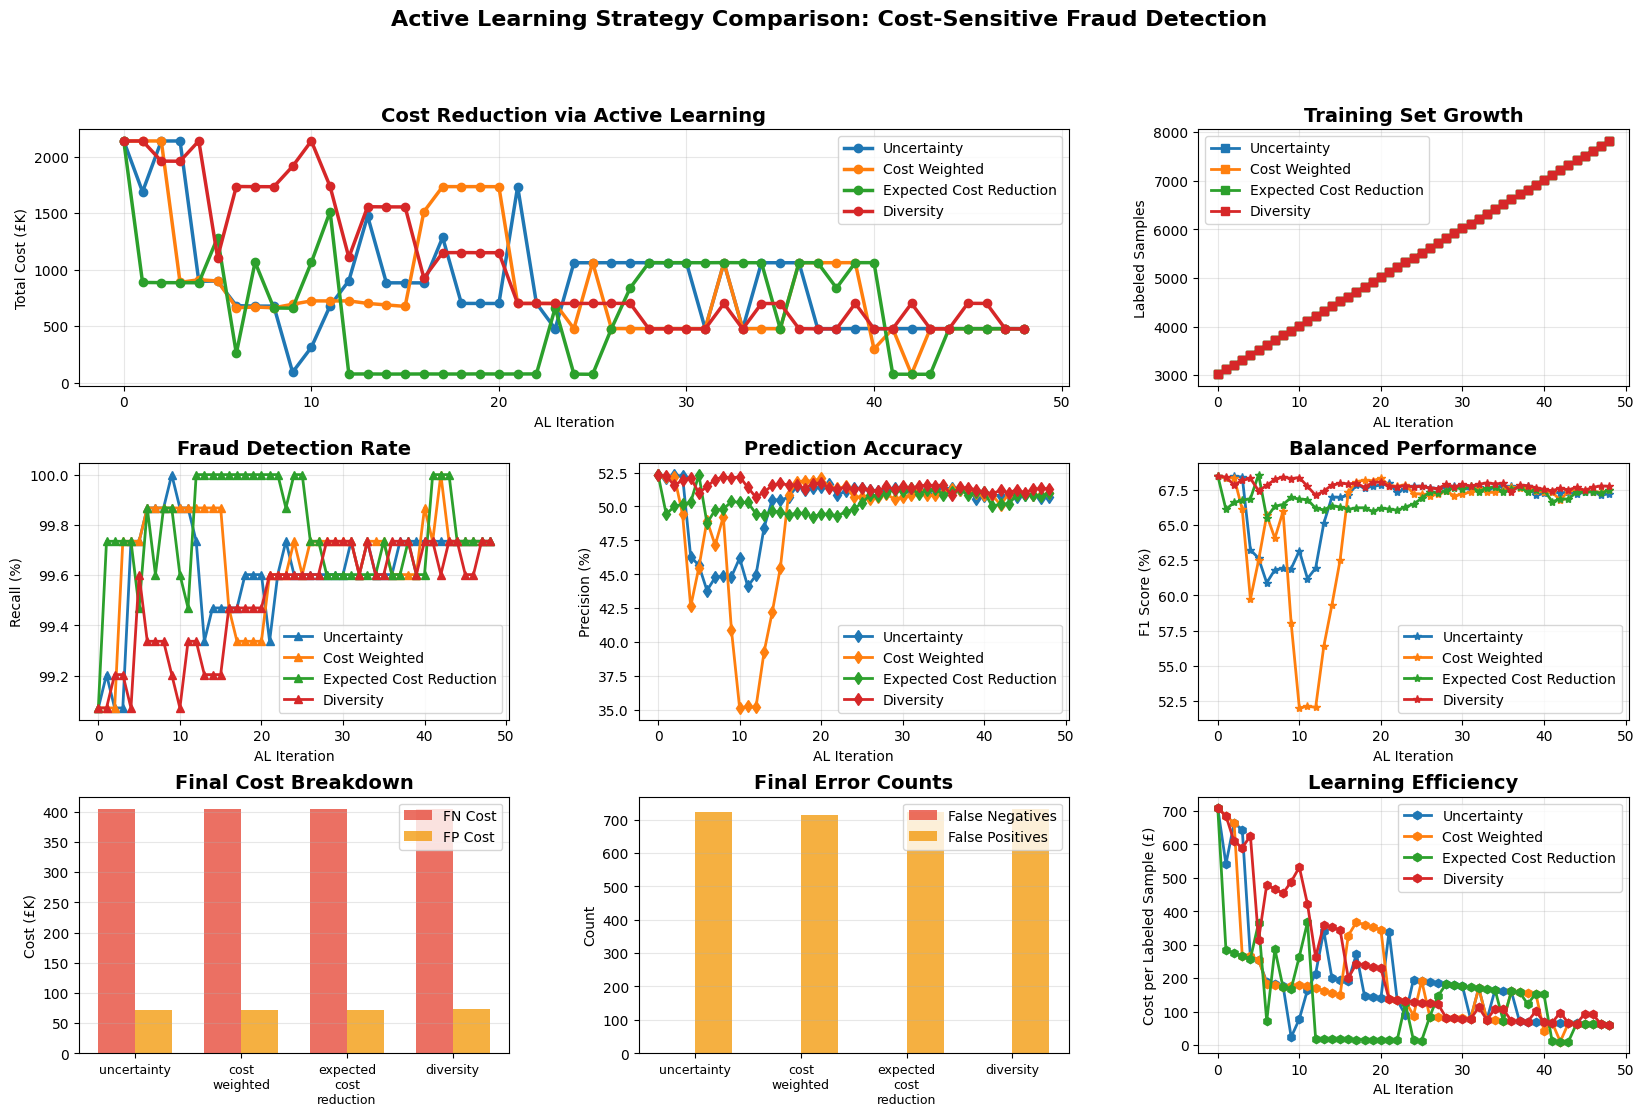


FINAL PERFORMANCE SUMMARY (Last Iteration)
                         Total Cost (£)  Recall (%)  Precision (%)  F1 (%)  \
strategy                                                                     
diversity                      476400.0       99.73          51.30   67.75   
expected_cost_reduction        477200.0       99.73          51.02   67.50   
cost_weighted                  477300.0       99.73          50.98   67.47   
uncertainty                    478200.0       99.73          50.67   67.20   

                         Labeled Samples  
strategy                                  
diversity                           7819  
expected_cost_reduction             7819  
cost_weighted                       7819  
uncertainty                         7819  


In [37]:
# ==================== USAGE ====================
results_al = compare_active_learning(df, sample_size=50000, n_iterations=48, query_budget=100)

In [27]:
import numpy as np
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier
from sklearn.cluster import MiniBatchKMeans
from sklearn.metrics import confusion_matrix, precision_recall_fscore_support, roc_auc_score
from scipy.optimize import minimize
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings("ignore")
np.random.seed(42)

# ==================== SHARED COST FUNCTIONS ====================
def calculate_costs(sum_insured, y_true, y_pred):
    """FN: 90% of sum_insured, FP: £100"""
    sum_insured = np.asarray(sum_insured)
    y_true, y_pred = np.asarray(y_true), np.asarray(y_pred)
    costs = np.zeros(len(y_true), dtype=float)
    fn_mask = (y_true == 1) & (y_pred == 0)
    fp_mask = (y_true == 0) & (y_pred == 1)
    costs[fn_mask] = sum_insured[fn_mask] * 0.90
    costs[fp_mask] = 100.0
    return costs

def evaluate_cost_sensitive(y_true, y_pred, sum_insured):
    """Comprehensive evaluation"""
    costs = calculate_costs(sum_insured, y_true, y_pred)
    fn_mask = (y_true == 1) & (y_pred == 0)
    fp_mask = (y_true == 0) & (y_pred == 1)
    precision, recall, f1, _ = precision_recall_fscore_support(y_true, y_pred, average='binary', zero_division=0)
    try:
        rocauc = roc_auc_score(y_true, y_pred)
    except:
        rocauc = np.nan
    return {
        'total_cost': float(costs.sum()),
        'fn_cost': float(costs[fn_mask].sum()),
        'fp_cost': float(costs[fp_mask].sum()),
        'fn_count': int(fn_mask.sum()),
        'fp_count': int(fp_mask.sum()),
        'tp': int(((y_true == 1) & (y_pred == 1)).sum()),
        'tn': int(((y_true == 0) & (y_pred == 0)).sum()),
        'precision': float(precision),
        'recall': float(recall),
        'f1': float(f1),
        'roc_auc': float(rocauc)
    }

def prepare_data(df, label_col='fraud_label', sum_col='sum_insured'):
    """Feature preparation"""
    feature_template = ['tier', 'tier_premium_amt', 'occupants_count', 'paying_guest_no',
        'unoccupied_days', 'sum_insured', 'premium_with_tax', 'risk_premium_with_credit_score',
        'risk_premium_without_credit_score', 'additional_coverage_amount', 'tier_limit_value',
        'item_limit_value', 'main_part_premium', 'accidental_damage_premium', 'outbuildings_premium',
        'APR_FLAG', 'previous_insurance_buildings', 'previous_insurance_cne', 'property_eligibility',
        'contents_claim_counts', 'building_claim_count', 'flood_risk', 'storm_risk',
        'other_natural_calamities_risk', 'property_age', 'no_of_rooms', 'plumbing_elec_age',
        'smart_home', 'fire_safety_systems', 'security_systems', 'crime_rate', 'no_of_claims_5yr',
        'premium_payment_behaviour', 'property_market_value', 'short_term_letting']
    categorical_template = ['cust_occupation', 'owner_details', 'property_type',
                           'construction_material', 'roof_material', 'urban_rural', 'policy_product']

    feature_cols = [c for c in feature_template if c in df.columns and c != label_col]
    categorical_cols = [c for c in categorical_template if c in df.columns]
    if not feature_cols:
        numeric_cols = df.select_dtypes(include=[np.number]).columns.tolist()
        feature_cols = [c for c in numeric_cols if c not in [label_col, sum_col]]

    df_enc = pd.get_dummies(df, columns=categorical_cols, drop_first=True)
    all_features = [c for c in df_enc.columns if (c in feature_cols) or any(cat in c for cat in categorical_cols)]
    if not all_features:
        all_features = [c for c in df_enc.select_dtypes(include=[np.number]).columns if c not in [label_col, sum_col]]

    X = df_enc[all_features].fillna(0).values
    y = df_enc[label_col].values
    sum_insured = df_enc[sum_col].values if sum_col in df_enc.columns else np.zeros(len(df_enc))
    return X, y, sum_insured, all_features

def find_optimal_threshold(model, X, y, sum_insured):
    """Find cost-minimizing threshold"""
    proba = model.predict_proba(X)[:, 1]
    thresholds = np.linspace(0.05, 0.95, 50)
    best_cost, best_t = np.inf, 0.5
    for t in thresholds:
        y_pred = (proba >= t).astype(int)
        cost = calculate_costs(sum_insured, y, y_pred).sum()
        if cost < best_cost:
            best_cost, best_t = cost, t
    return best_t

def find_optimal_threshold_from_proba(proba, y, sum_insured):
    """Find cost-minimizing threshold given predicted probabilities."""
    thresholds = np.linspace(0.05, 0.95, 50)
    best_cost, best_t = np.inf, 0.5
    for t in thresholds:
        y_pred = (proba >= t).astype(int)
        cost = calculate_costs(sum_insured, y, y_pred).sum()
        if cost < best_cost:
            best_cost, best_t = cost, t
    return best_t

# ==================== BASELINE ML MODELS ====================
class CostSensitiveClassifier:
    """Wrapper for threshold optimization"""
    def __init__(self, base_clf):
        self.clf = base_clf
        self.opt_threshold = 0.5

    def fit(self, X, y, sum_insured=None):
        self.clf.fit(X, y)
        if sum_insured is not None and hasattr(self.clf, "predict_proba"):
            self.opt_threshold = find_optimal_threshold(self.clf, X, y, sum_insured)
        return self

    def predict(self, X):
        if hasattr(self.clf, "predict_proba"):
            proba = self.clf.predict_proba(X)[:, 1]
            return (proba >= self.opt_threshold).astype(int)
        return self.clf.predict(X)

# -------------------------
# IDCSPA: Instance-Dependent Cost-Sensitive Passive-Aggressive
# -------------------------
class IDCSPA:
    def __init__(self, C=1.0, fp_cost=100, fn_multiplier=0.9):
        self.C = float(C)
        self.theta = None
        self.fp_cost = float(fp_cost)
        self.fn_multiplier = float(fn_multiplier)

    def fit(self, X, y, sum_insured, epochs=3):
        """
        Online updates. y in {0,1} internally; uses unified cost model.
        """
        n, d = X.shape
        self.theta = np.zeros(d, dtype=float)
        y_signed = (2 * np.asarray(y).astype(int)) - 1

        for epoch in range(epochs):
            idx = np.random.permutation(n)
            for i in idx:
                x_i = X[i]
                y_i = y_signed[i]
                w_i = float(sum_insured[i])

                y_pred_raw = np.sign(self.theta.dot(x_i))
                if y_pred_raw == 0:
                    y_pred_raw = -1

                # use unified costs
                if y_pred_raw == -1 and y_i == 1:   # FN
                    loss = w_i * self.fn_multiplier
                elif y_pred_raw == 1 and y_i == -1:  # FP
                    loss = self.fp_cost
                else:
                    loss = 0.0

                if loss > 0:
                    numerator = (y_pred_raw - y_i) * (self.theta.dot(x_i)) + np.sqrt(loss)
                    denom = np.linalg.norm((y_pred_raw - y_i) * x_i) ** 2
                    if denom <= 0:
                        continue
                    tau = min(self.C, max(0.0, numerator / denom))
                    self.theta += tau * (y_i - y_pred_raw) * x_i
        return self

    def predict(self, X):
        preds = np.sign(X.dot(self.theta))
        preds[preds == 0] = -1
        return ((preds + 1) / 2).astype(int)

    def decision_function(self, X):
        return X.dot(self.theta)

# -------------------------
# CSLB: Cost-Sensitive Logistic Bandit (cost-aligned surrogate objective)
# -------------------------
class CSLB:
    def __init__(self, alpha=1.0, lam=1e-3, maxiter=200,
                 fp_cost=100, fn_multiplier=0.9):
        """
        alpha: prior scaling for initial covariance
        lam: L2 regularization
        maxiter: L-BFGS max iterations
        fp_cost, fn_multiplier: unified cost parameters
        """
        self.alpha = float(alpha)
        self.lam = float(lam)
        self.maxiter = int(maxiter)
        self.theta_mean = None
        self.theta_cov = None
        self.fp_cost = float(fp_cost)
        self.fn_multiplier = float(fn_multiplier)

    def _sigmoid(self, z):
        return 1.0 / (1.0 + np.exp(-np.clip(z, -500, 500)))

    def _compute_threshold(self, sum_insured):
        """
        Per-instance decision threshold consistent with evaluation:
          h(w) = FP / (FP + FN)
        """
        w = float(sum_insured)
        FP = float(self.fp_cost)
        FN = float(self.fn_multiplier) * w
        denom = FP + FN
        if denom <= 0:
            return 0.5
        return float(np.clip(FP / denom, 0.0, 1.0))

    def _obj_and_grad(self, theta, X, y, sum_ins_scaled):
        """
        Minimize average expected cost of a stochastic policy that flags with prob p=sigma(X theta).
        Per-sample expected cost:
            E[cost] = y*(1-p)*FN + (1-y)*p*FP
        This is differentiable and aligns training with evaluation.
        Returns (obj, grad)
        """
        n = X.shape[0]
        z = X.dot(theta)
        p = self._sigmoid(z)  # (n,)

        # recover true FN and FP per (scaled) sums; note we used scaled sums for optimization
        # the actual FN scale will be accounted by scaling factor (handled when building sum_ins_scaled)
        FN_vec = self.fn_multiplier * sum_ins_scaled  # per-sample FN (scaled)
        FP = self.fp_cost  # scalar

        # average expected cost
        cost_vec = y * (1 - p) * FN_vec + (1 - y) * p * FP
        obj = float(cost_vec.mean() + 0.5 * self.lam * np.dot(theta, theta))

        # gradient: for sample i, d/dtheta = p*(1-p)*x_i * ( - y_i * FN_i + (1 - y_i) * FP )
        coeff = ( - y * FN_vec + (1 - y) * FP ) * (p * (1 - p))  # (n,)
        grad = (X.T.dot(coeff) / max(1, n)) + self.lam * theta

        return obj, grad

    def fit(self, X, y, sum_insured):
        """
        Fit by optimizing the differentiable expected-cost surrogate.
        We scale sum_insured internally for numeric stability.
        """
        X = np.asarray(X)
        y = np.asarray(y).astype(int)
        n, d = X.shape

        if self.theta_mean is None:
            self.theta_mean = np.zeros(d, dtype=float)
            self.theta_cov = np.eye(d) * self.alpha

        # scale sums for optimization
        scale = (np.mean(sum_insured) + 1e-9)
        sum_scaled = np.asarray(sum_insured, dtype=float) / scale

        def fun(theta):
            return self._obj_and_grad(theta, X, y, sum_scaled)

        res = minimize(fun, self.theta_mean, method='L-BFGS-B', jac=True,
                       options={'maxiter': self.maxiter, 'disp': False})

        # accept best found solution
        self.theta_mean = res.x

        # Hessian (Laplace approx) compute with regularization
        eps = 1e-6
        z = X.dot(self.theta_mean)
        p = self._sigmoid(z)
        W = p * (1 - p)
        X_weighted = X * W[:, None]
        H = (X.T.dot(X_weighted) / max(1, n)) + (eps + self.lam) * np.eye(d)

        try:
            self.theta_cov = np.linalg.inv(H)
        except np.linalg.LinAlgError:
            self.theta_cov = np.linalg.pinv(H)

        return self

    def predict(self, X, sum_insured):
        """
        Thompson sampling: sample one theta from posterior, then apply per-instance threshold h(w).
        """
        if self.theta_mean is None:
            raise ValueError("CSLB not fitted")

        try:
            theta_sample = np.random.multivariate_normal(self.theta_mean, self.theta_cov)
        except Exception:
            theta_sample = self.theta_mean.copy()

        p = self._sigmoid(X.dot(theta_sample))
        thresholds = np.array([self._compute_threshold(w) for w in np.atleast_1d(sum_insured)])
        return (p >= thresholds).astype(int)

    def predict_proba(self, X):
        if self.theta_mean is None:
            raise ValueError("CSLB not fitted")
        probs = self._sigmoid(X.dot(self.theta_mean))
        return np.vstack([1 - probs, probs]).T

# ==================== ACTIVE LEARNING ====================
def apply_fraud_rules(df):
    """Rule-based seeding"""
    flags = pd.Series(False, index=df.index)
    claim_ratio = df['sum_insured'] / (df['premium_with_tax'] + 1)
    flags |= (claim_ratio > 1500) & (df['previous_insurance_buildings'] == 0) & (df['no_of_claims_5yr'] > 0)
    flags |= (df['accidental_damage_premium'] > 0) & (df['unoccupied_days'] >= 30) & (df['no_of_claims_5yr'] > 0)
    flags |= (df['no_of_claims_5yr'] >= 3)
    return flags

# ==================== UNIFIED AL WRAPPER ====================
class UnifiedALModel:
    """Wrapper supporting all model types"""
    def __init__(self, model_type='xgboost'):
        self.model_type = model_type
        self.model = None
        self.threshold = 0.5

    def _create_base_model(self):
        if self.model_type == 'logistic':
            return LogisticRegression(max_iter=1000, class_weight='balanced', random_state=42)
        elif self.model_type == 'decision_tree':
            return DecisionTreeClassifier(max_depth=10, min_samples_split=50, min_samples_leaf=20,
                                         class_weight='balanced', random_state=42)
        elif self.model_type == 'random_forest':
            return RandomForestClassifier(n_estimators=100, max_depth=10, min_samples_split=50,
                                         class_weight='balanced', random_state=42)
        elif self.model_type == 'xgboost':
            return XGBClassifier(n_estimators=100, max_depth=6, learning_rate=0.1,
                         random_state=42, use_label_encoder=False, eval_metric='logloss', n_jobs=-1)
        elif self.model_type == 'idcspa':
            return IDCSPA(C=1.0)
        elif self.model_type == 'cslb':
            return CSLB(alpha=1.0, lam=0.1)

    def fit(self, X, y, sum_insured):
        self.model = self._create_base_model()

        # XGBoost: cost-aware weighting + scale_pos_weight
        if self.model_type == 'xgboost':
            pos_weight = (y == 0).sum() / max(1, (y == 1).sum())
            # rebuild model with scale_pos_weight
            self.model = XGBClassifier(n_estimators=100, max_depth=6, learning_rate=0.1,
                                      random_state=42, use_label_encoder=False,
                                      eval_metric='logloss', n_jobs=-1,
                                      scale_pos_weight=pos_weight)
            # fit without sample_weight (keep training stable)
            self.model.fit(X, y)

        # RL models: pass sum_insured
        elif self.model_type in ['idcspa', 'cslb']:
            self.model.fit(X, y, sum_insured)
        # Standard sklearn
        else:
            self.model.fit(X, y)

        # Find optimal threshold
        if hasattr(self.model, "predict_proba"):
            proba = self.model.predict_proba(X)[:, 1]
        elif hasattr(self.model, "decision_function"):
            scores = self.model.decision_function(X)
            proba = 1.0 / (1.0 + np.exp(-scores))
        else:
            # fallback to hard predictions (0/1) as probabilities if nothing else available
            preds = self.model.predict(X) if hasattr(self.model, "predict") else np.zeros(len(X))
            proba = preds.astype(float)

        # use the proba-based threshold finder (this avoids requiring model.predict_proba inside)
        self.threshold = find_optimal_threshold_from_proba(proba, y, sum_insured)
        return self

    def predict_proba(self, X):
      # Native probability models
      if hasattr(self.model, "predict_proba"):
          return self.model.predict_proba(X)

      # IDCSPA fallback → decision_function → sigmoid
      if hasattr(self.model, "decision_function"):
          scores = self.model.decision_function(X)
          probs = 1.0 / (1.0 + np.exp(-scores))
          return np.vstack([1 - probs, probs]).T

      # Last fallback → hard predictions
      preds = self.model.predict(X).astype(float)
      return np.vstack([1 - preds, preds]).T

    def predict(self, X, sum_insured=None):
      # CSLB has its own predict signature
      if self.model_type == 'cslb' and sum_insured is not None:
          return self.model.predict(X, sum_insured)

      # If model supports predict_proba (sklearn, CSLB)
      if hasattr(self.model, "predict_proba"):
          proba = self.model.predict_proba(X)[:, 1]

      # IDCSPA fallback → use decision_function → sigmoid
      elif hasattr(self.model, "decision_function"):
          scores = self.model.decision_function(X)
          proba = 1.0 / (1.0 + np.exp(-scores))

      # Last-resort fallback → hard predictions
      else:
          preds = self.model.predict(X)
          proba = preds.astype(float)

      return (proba >= self.threshold).astype(int)

# ==================== ACTIVE LEARNER ====================
class ActiveLearner:
    def __init__(self, model_type='xgboost', strategy='uncertainty'):
        self.model_type = model_type
        self.strategy = strategy
        self.model = UnifiedALModel(model_type)
        self.scaler = StandardScaler()
        self.labeled_X = None
        self.labeled_y = None
        self.labeled_sum = None

    def initialize(self, X_init, y_init, sum_init):
        self.labeled_X = self.scaler.fit_transform(X_init)
        self.labeled_y = y_init.copy()
        self.labeled_sum = sum_init.copy()
        self.model.fit(self.labeled_X, self.labeled_y, self.labeled_sum)

    def query(self, X_pool, sum_pool, budget):
        X_scaled = self.scaler.transform(X_pool)
        proba = self.model.predict_proba(X_scaled)[:, 1]

        if self.strategy == 'uncertainty':
            scores = np.abs(proba - 0.5)
            indices = np.argsort(scores)[:budget]
        elif self.strategy == 'cost_weighted':
            uncertainty = 0.5 - np.abs(proba - 0.5)
            norm_cost = sum_pool / (sum_pool.max() + 1)
            scores = uncertainty * norm_cost
            indices = np.argsort(-scores)[:budget]
        elif self.strategy == 'expected_cost_reduction':
            risk_if_0 = proba * (sum_pool * 0.9)
            risk_if_1 = (1 - proba) * 100
            current_risk = np.where(proba < self.model.threshold, risk_if_0, risk_if_1)
            indices = np.argsort(-current_risk)[:budget]
        elif self.strategy == 'diversity':
            n_clusters = min(budget, len(X_scaled) // 2)
            kmeans = MiniBatchKMeans(n_clusters=n_clusters, random_state=42, batch_size=256)
            kmeans.fit(X_scaled)
            dists = np.min(kmeans.transform(X_scaled), axis=1)
            uncertainty = 1 - np.abs(2 * proba - 1)
            scores = uncertainty + 0.5 * (dists / (dists.max() + 1e-6))
            indices = np.argsort(-scores)[:budget]

        return indices

    def update(self, X_new, y_new, sum_new):
        X_new_scaled = self.scaler.transform(X_new)
        self.labeled_X = np.vstack([self.labeled_X, X_new_scaled])
        self.labeled_y = np.concatenate([self.labeled_y, y_new])
        self.labeled_sum = np.concatenate([self.labeled_sum, sum_new])
        self.model.fit(self.labeled_X, self.labeled_y, self.labeled_sum)

    def predict(self, X, sum_insured=None):
        X_scaled = self.scaler.transform(X)
        return self.model.predict(X_scaled, sum_insured)

# ==================== MAIN COMPARISON ====================
def compare_all_models_al(df, sample_size=20000, n_iterations=12, query_budget=100, random_state=42,
                          models = ['logistic', 'decision_tree', 'random_forest', 'xgboost', 'idcspa', 'cslb'],
                          strategies = ['uncertainty', 'cost_weighted', 'expected_cost_reduction', 'diversity']):
    """Compare all 6 models × 4 strategies = 24 combinations"""

    print("="*80)
    print("ACTIVE LEARNING: ALL MODELS × ALL STRATEGIES")
    print("="*80)

    # Sample and split (same as baseline)
    counts = df['fraud_label'].value_counts()
    sampled_parts = []
    for label in counts.index:
        group = df[df['fraud_label'] == label]
        n_samples = int(sample_size * len(group) / len(df))
        sampled_parts.append(group.sample(n=min(n_samples, len(group)), random_state=random_state))

    df_sample = pd.concat(sampled_parts, ignore_index=True).sample(frac=1.0, random_state=random_state).reset_index(drop=True)
    X, y, sum_ins, _ = prepare_data(df_sample)

    X_train_pool, X_test, y_train_pool, y_test, sum_train_pool, sum_test = train_test_split(
        X, y, sum_ins, test_size=0.30, random_state=random_state, stratify=y
    )

    print(f"Train pool: {len(X_train_pool)}, Test: {len(X_test)}")
    print(f"Fraud rate - Train: {y_train_pool.mean():.2%}, Test: {y_test.mean():.2%}\n")

    # Rule-based initialization
    df_train_pool = df_sample.iloc[:len(X_train_pool)].copy()
    df_train_pool['fraud_label'] = y_train_pool
    df_train_pool['sum_insured'] = sum_train_pool
    rule_flags = apply_fraud_rules(df_train_pool)
    flagged_indices = np.where(rule_flags.values)[0]

    print(f"Initial labeled: {len(flagged_indices)} ({len(flagged_indices)/len(X_train_pool)*100:.1f}%)")
    print(f"Query budget: {query_budget}, Iterations: {n_iterations}\n")

    X_init = X_train_pool[flagged_indices]
    y_init = y_train_pool[flagged_indices]
    sum_init = sum_train_pool[flagged_indices]
    unlabeled_mask = np.ones(len(X_train_pool), dtype=bool)
    unlabeled_mask[flagged_indices] = False

    results = []

    for model_type in models:
        for strategy in strategies:
            combo = f"{model_type}_{strategy}"
            print(f"Running: {combo}")

            learner = ActiveLearner(model_type=model_type, strategy=strategy)
            learner.initialize(X_init, y_init, sum_init)
            current_unlabeled = unlabeled_mask.copy()

            # Baseline
            y_pred = learner.predict(X_test, sum_test if model_type == 'cslb' else None)
            metrics = evaluate_cost_sensitive(y_test, y_pred, sum_test)
            metrics.update({'model': model_type, 'strategy': strategy, 'iteration': 0, 'labeled_count': len(y_init)})
            results.append(metrics)

            # AL loop
            for iteration in range(1, n_iterations + 1):
                unlabeled_indices = np.where(current_unlabeled)[0]
                if len(unlabeled_indices) < query_budget:
                    break

                X_pool = X_train_pool[unlabeled_indices]
                sum_pool = sum_train_pool[unlabeled_indices]
                query_idx_local = learner.query(X_pool, sum_pool, query_budget)
                query_idx_global = unlabeled_indices[query_idx_local]

                X_new = X_train_pool[query_idx_global]
                y_new = y_train_pool[query_idx_global]
                sum_new = sum_train_pool[query_idx_global]
                learner.update(X_new, y_new, sum_new)
                current_unlabeled[query_idx_global] = False

                y_pred = learner.predict(X_test, sum_test if model_type == 'cslb' else None)
                metrics = evaluate_cost_sensitive(y_test, y_pred, sum_test)
                metrics.update({'model': model_type, 'strategy': strategy, 'iteration': iteration,
                              'labeled_count': len(y_init) + (iteration * query_budget)})
                results.append(metrics)

    results_df = pd.DataFrame(results)
    visualize_all_models_al(results_df, models, strategies)
    return results_df

def visualize_all_models_al(df, models, strategies):
    """Comprehensive visualization"""

    # 1. Cost comparison: Models × Strategies
    fig, axes = plt.subplots(2, 2, figsize=(20, 16))

    for idx, strategy in enumerate(strategies):
        ax = axes[idx // 2, idx % 2]
        for model in models:
            data = df[(df['model'] == model) & (df['strategy'] == strategy)]
            ax.plot(data['iteration'], data['total_cost']/1000, marker='o',
                   label=model.replace('_', ' ').title(), linewidth=2)
        ax.set_xlabel('Iteration')
        ax.set_ylabel('Total Cost (£K)')
        ax.set_title(f'Strategy: {strategy.replace("_", " ").title()}', fontweight='bold', fontsize=13)
        ax.legend()
        ax.grid(alpha=0.3)

    plt.suptitle('Cost Reduction: All Models × All AL Strategies', fontsize=16, fontweight='bold')
    plt.tight_layout()
    plt.show()

    # 2. Final performance heatmap
    final = df[df['iteration'] == df['iteration'].max()].pivot_table(
        index='model', columns='strategy', values='total_cost', aggfunc='first'
    )

    plt.figure(figsize=(12, 8))
    sns.heatmap(final/1000, annot=True, fmt='.0f', cmap='RdYlGn_r', cbar_kws={'label': 'Cost (£K)'})
    plt.title('Final Cost Heatmap: Models × Strategies', fontweight='bold', fontsize=14)
    plt.ylabel('Model')
    plt.xlabel('AL Strategy')
    plt.tight_layout()
    plt.show()

    # 3. Best strategy per model
    plt.figure(figsize=(16, 6))
    for model in models:
        model_data = df[df['model'] == model]
        best_strat = model_data[model_data['iteration'] == model_data['iteration'].max()].groupby('strategy')['total_cost'].min().idxmin()
        best_data = model_data[model_data['strategy'] == best_strat]
        plt.plot(best_data['iteration'], best_data['total_cost']/1000,
                marker='o', linewidth=2.5, label=f"{model} (best: {best_strat})")

    plt.xlabel('Iteration')
    plt.ylabel('Total Cost (£K)')
    plt.title('Best AL Strategy per Model', fontweight='bold', fontsize=14)
    plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
    plt.grid(alpha=0.3)
    plt.tight_layout()
    plt.show()

    # 4. Summary table
    print("\n" + "="*100)
    print("FINAL PERFORMANCE SUMMARY (Last Iteration)")
    print("="*100)
    final_df = df[df['iteration'] == df['iteration'].max()].groupby(['model', 'strategy']).first()
    summary = pd.DataFrame({
        'Cost (£K)': final_df['total_cost'] / 1000,
        'Recall (%)': final_df['recall'] * 100,
        'F1 (%)': final_df['f1'] * 100,
        'Samples': final_df['labeled_count']
    }).round(2)

    best_per_model = summary.groupby('model')['Cost (£K)'].idxmin()
    print("\nBest Strategy per Model:")
    for model in models:
        best = best_per_model[best_per_model.index.get_level_values(0) == model].iloc[0]
        row = summary.loc[best]
        print(f"  {model.ljust(15)}: {best[1].ljust(25)} | Cost: £{row['Cost (£K)']:.0f}K | Recall: {row['Recall (%)']:.1f}% | F1: {row['F1 (%)']:.1f}%")

    print("\nTop 5 Overall:")
    print(summary.sort_values('Cost (£K)').head(10))

ACTIVE LEARNING: ALL MODELS × ALL STRATEGIES
Train pool: 34999, Test: 15000
Fraud rate - Train: 5.03%, Test: 5.03%

Initial labeled: 3019 (8.6%)
Query budget: 100, Iterations: 36

Running: logistic_uncertainty
Running: logistic_cost_weighted
Running: logistic_expected_cost_reduction
Running: logistic_diversity
Running: decision_tree_uncertainty
Running: decision_tree_cost_weighted
Running: decision_tree_expected_cost_reduction
Running: decision_tree_diversity
Running: random_forest_uncertainty
Running: random_forest_cost_weighted
Running: random_forest_expected_cost_reduction
Running: random_forest_diversity
Running: xgboost_uncertainty
Running: xgboost_cost_weighted
Running: xgboost_expected_cost_reduction
Running: xgboost_diversity
Running: idcspa_uncertainty
Running: idcspa_cost_weighted
Running: idcspa_expected_cost_reduction
Running: idcspa_diversity
Running: cslb_uncertainty
Running: cslb_cost_weighted
Running: cslb_expected_cost_reduction
Running: cslb_diversity


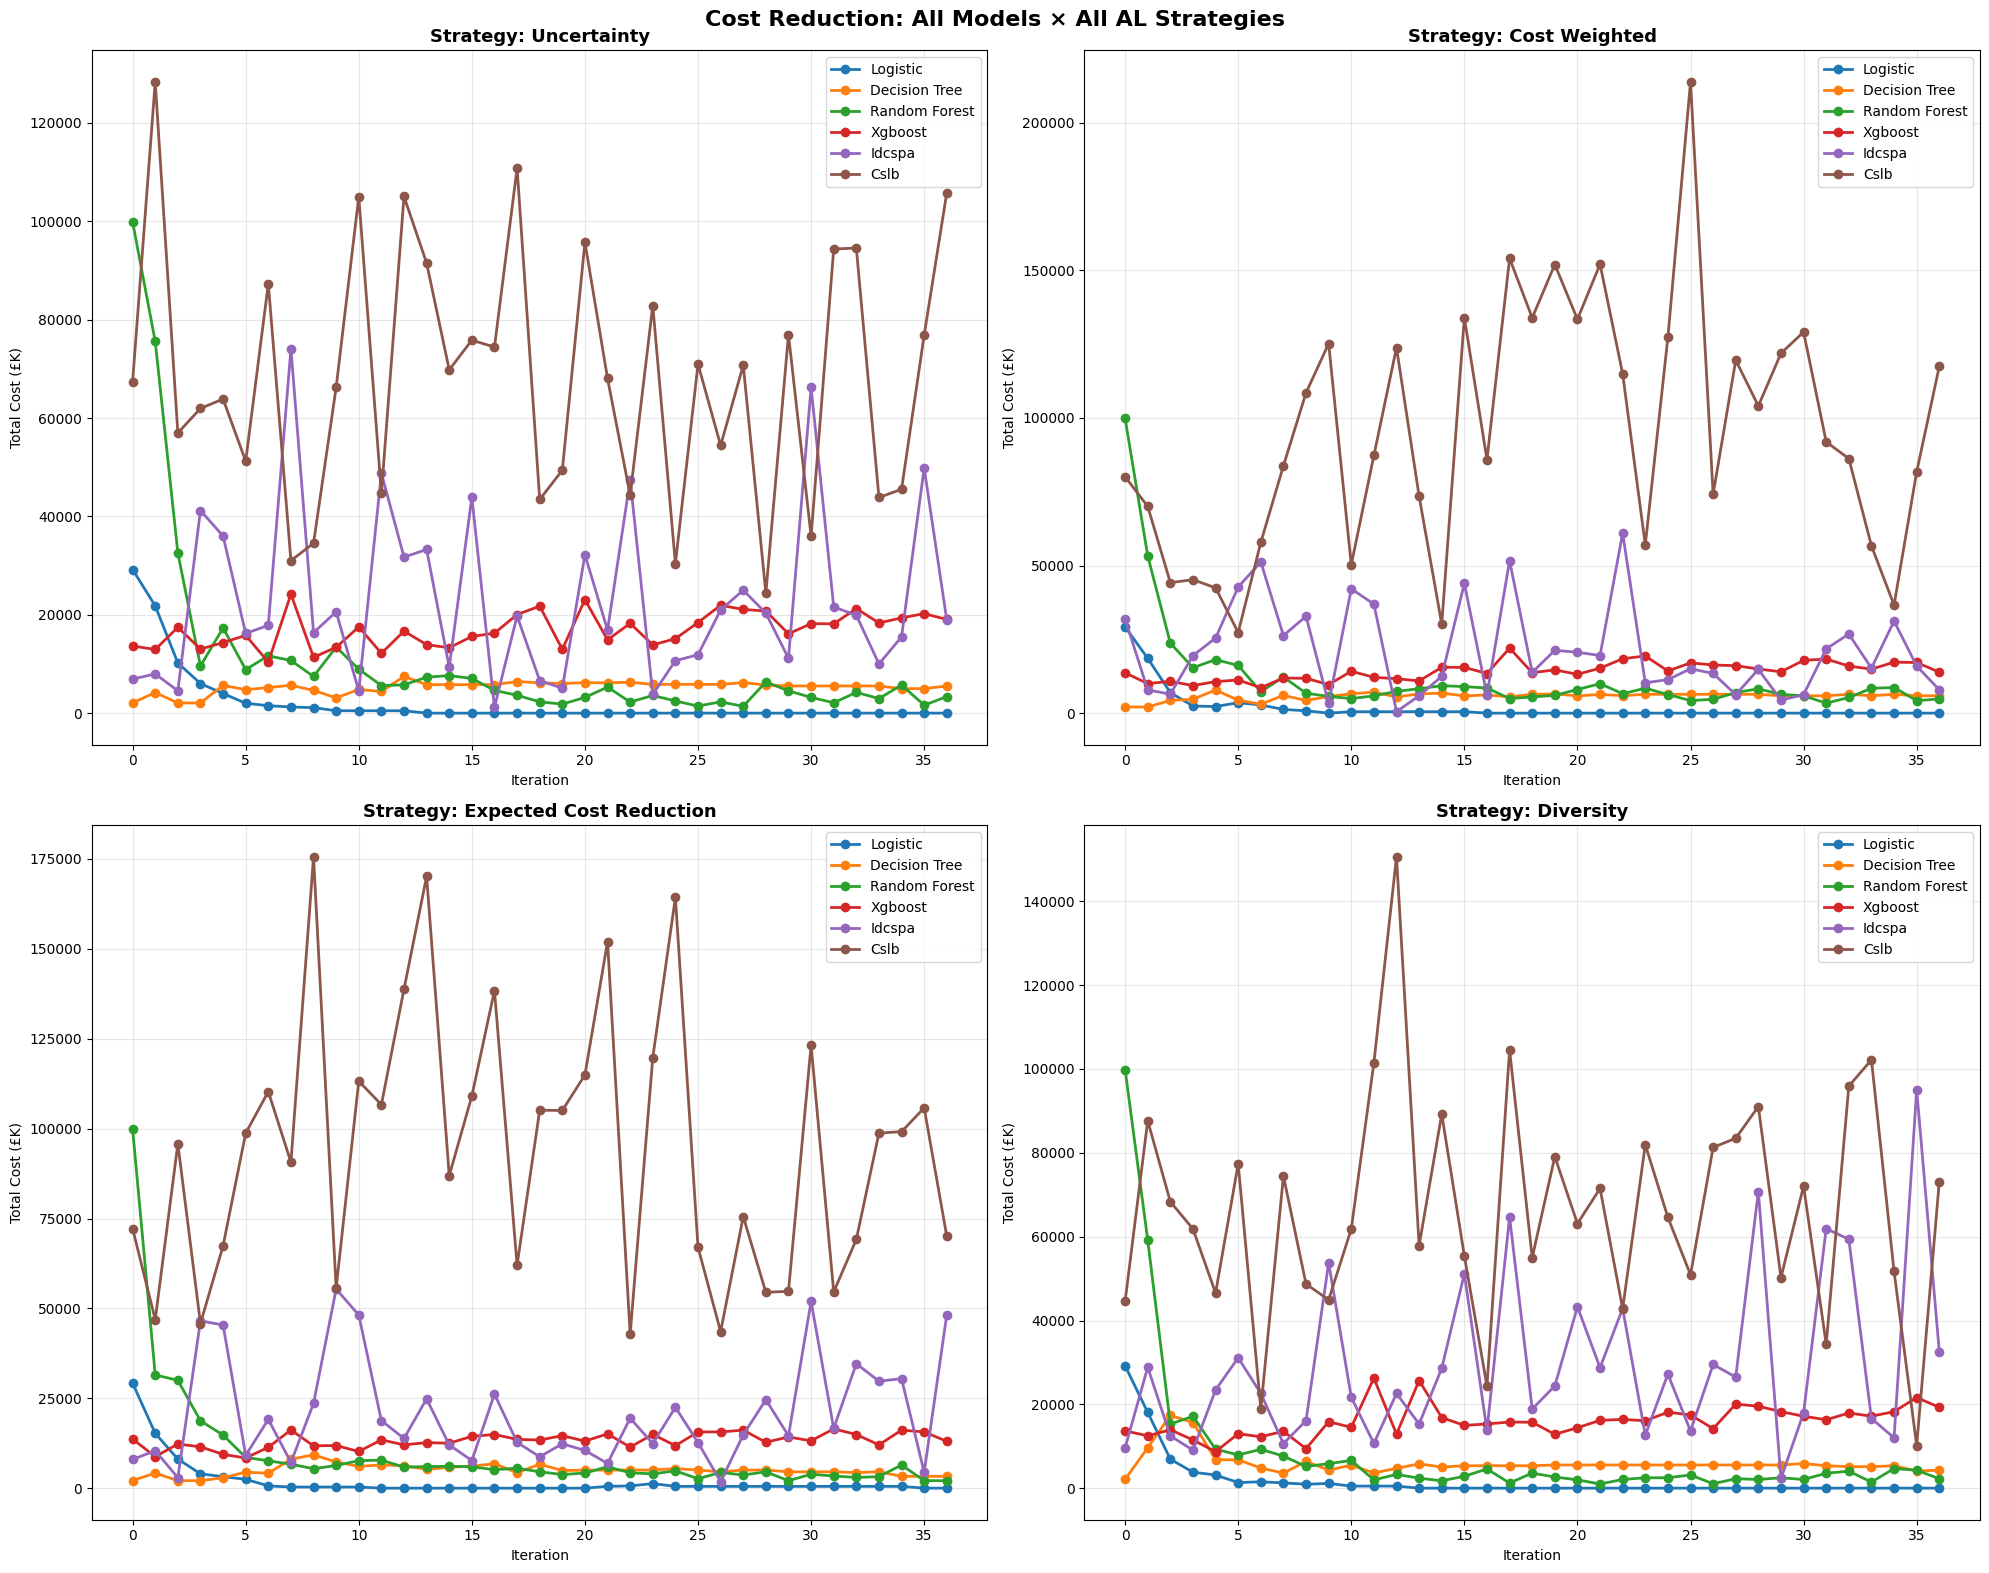

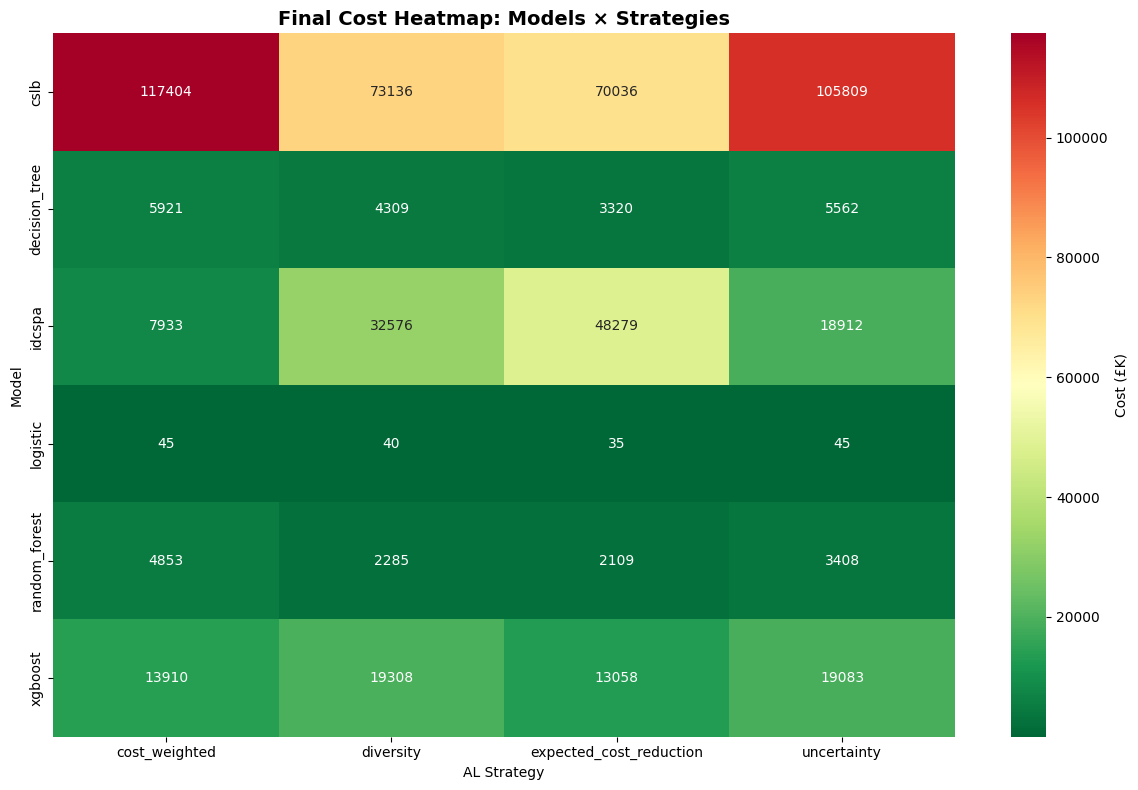

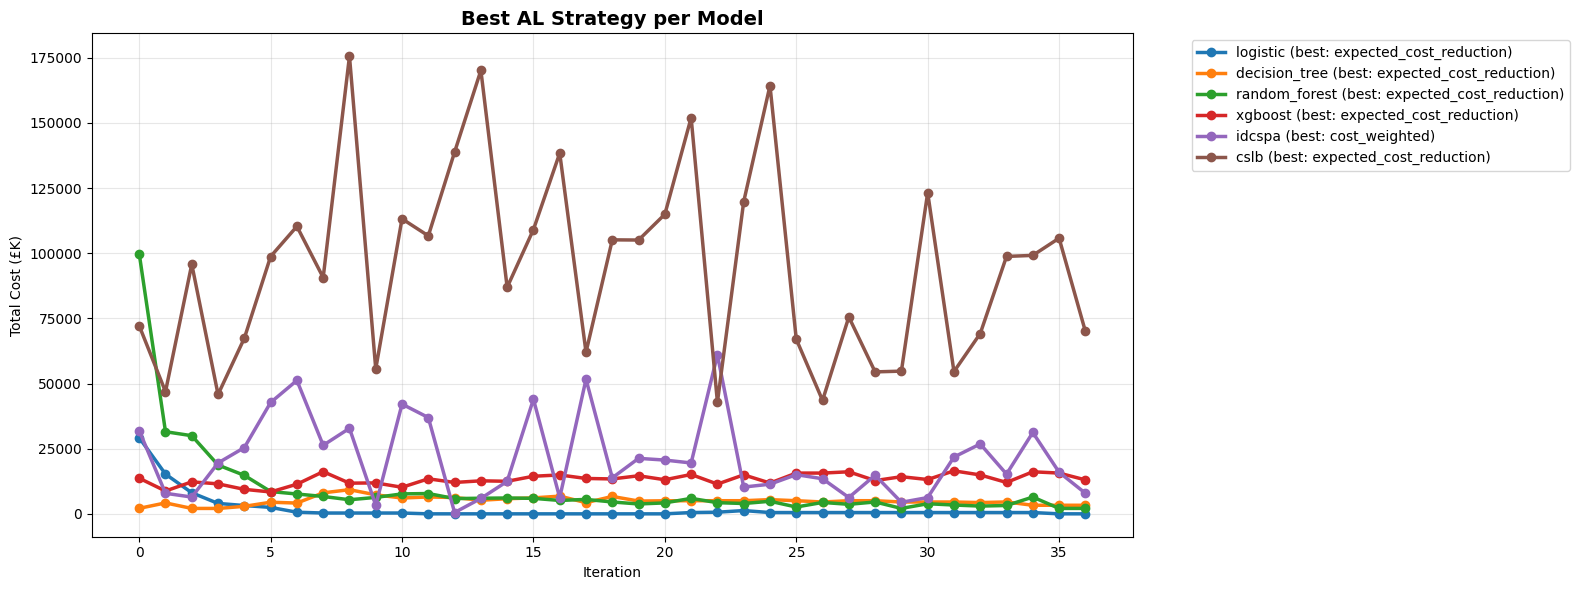


FINAL PERFORMANCE SUMMARY (Last Iteration)

Best Strategy per Model:
  logistic       : expected_cost_reduction   | Cost: £35K | Recall: 100.0% | F1: 81.0%
  decision_tree  : expected_cost_reduction   | Cost: £3320K | Recall: 98.9% | F1: 80.7%
  random_forest  : expected_cost_reduction   | Cost: £2109K | Recall: 99.1% | F1: 78.8%
  xgboost        : expected_cost_reduction   | Cost: £13058K | Recall: 94.6% | F1: 92.1%
  idcspa         : cost_weighted             | Cost: £7933K | Recall: 97.9% | F1: 15.2%
  cslb           : expected_cost_reduction   | Cost: £70036K | Recall: 78.4% | F1: 11.2%

Top 5 Overall:
                                       Cost (£K)  Recall (%)  F1 (%)  Samples
model         strategy                                                       
logistic      expected_cost_reduction       35.4      100.00   80.99     6619
              diversity                     39.5      100.00   79.24     6619
              cost_weighted                 44.6      100.00   77.18     

In [24]:
results_all = compare_all_models_al(
    df,
    sample_size=50000,
    n_iterations=36,
    query_budget=100,
    models = ['logistic', 'decision_tree', 'random_forest', 'xgboost', 'idcspa', 'cslb'],
    strategies = ['uncertainty', 'cost_weighted', 'expected_cost_reduction', 'diversity']
)

ACTIVE LEARNING: ALL MODELS × ALL STRATEGIES
Train pool: 34999, Test: 15000
Fraud rate - Train: 5.03%, Test: 5.03%

Initial labeled: 3019 (8.6%)
Query budget: 100, Iterations: 36

Running: logistic_uncertainty
Running: logistic_cost_weighted
Running: logistic_expected_cost_reduction
Running: logistic_diversity
Running: decision_tree_uncertainty
Running: decision_tree_cost_weighted
Running: decision_tree_expected_cost_reduction
Running: decision_tree_diversity
Running: random_forest_uncertainty
Running: random_forest_cost_weighted
Running: random_forest_expected_cost_reduction
Running: random_forest_diversity
Running: xgboost_uncertainty
Running: xgboost_cost_weighted
Running: xgboost_expected_cost_reduction
Running: xgboost_diversity


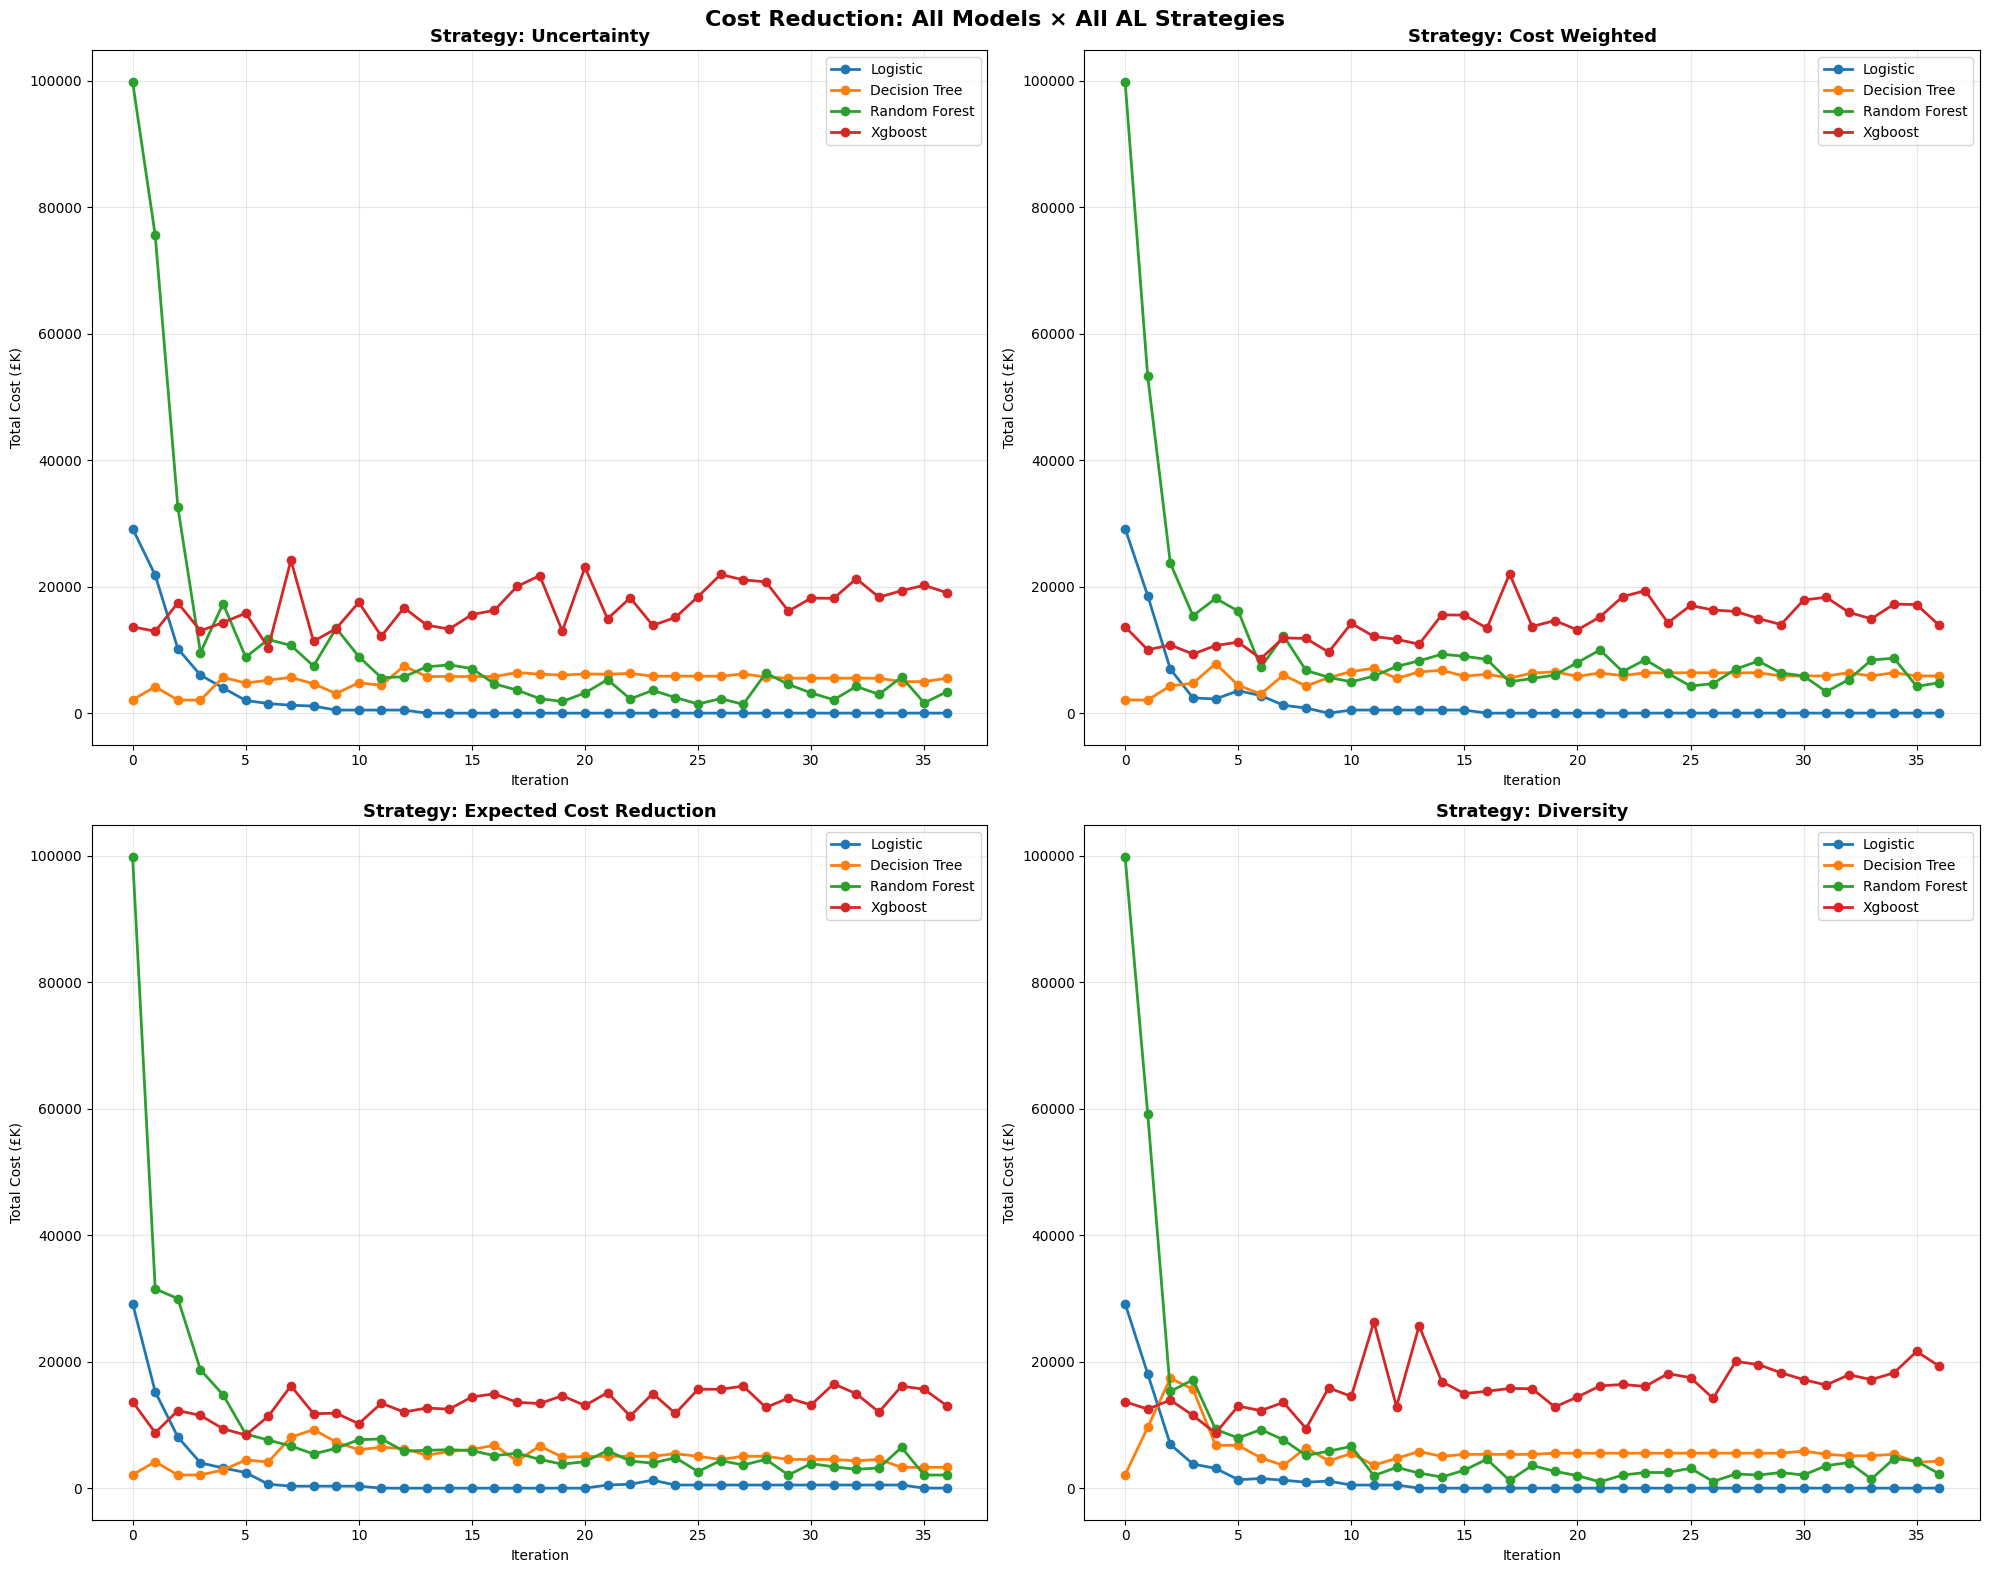

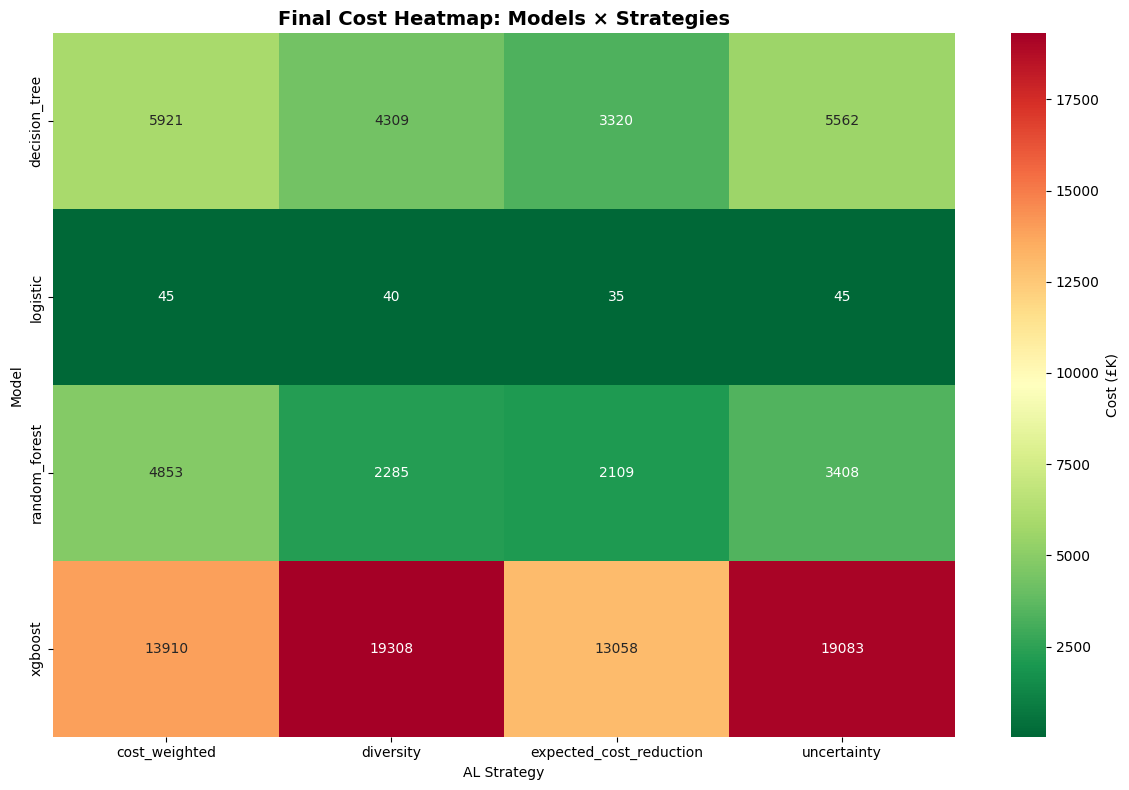

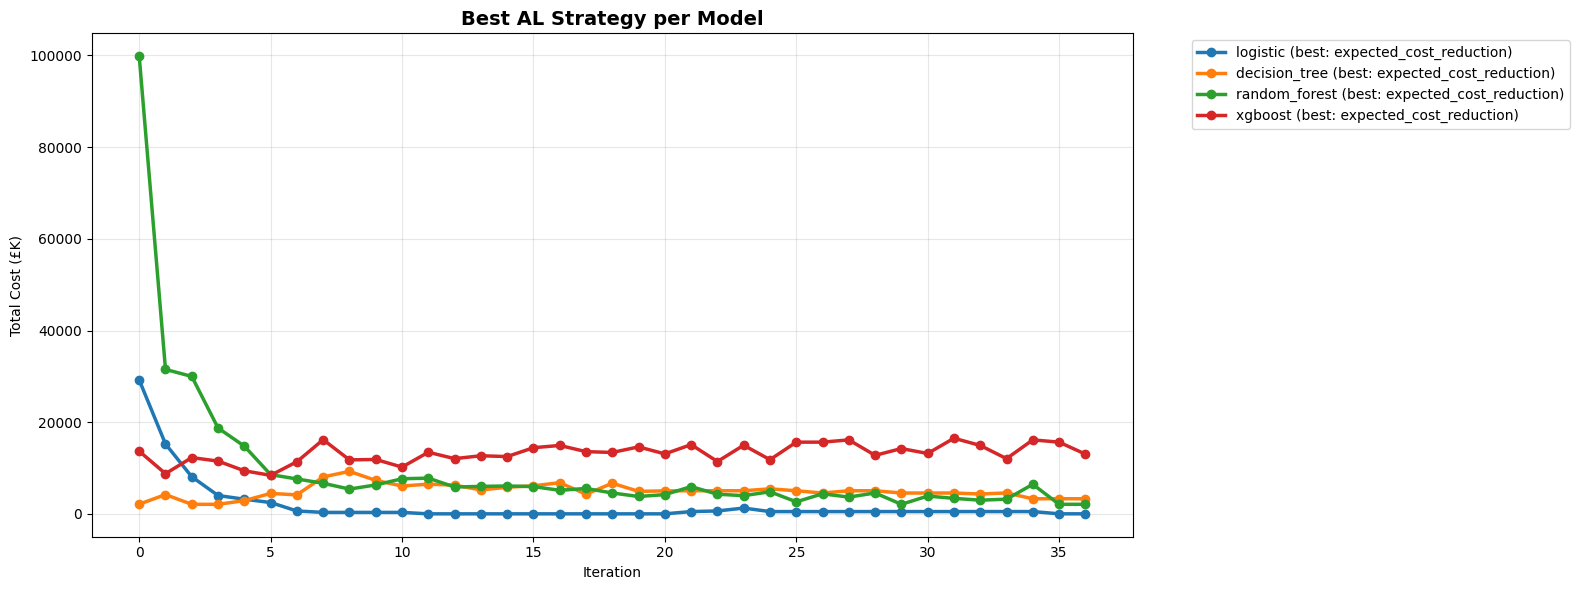


FINAL PERFORMANCE SUMMARY (Last Iteration)

Best Strategy per Model:
  logistic       : expected_cost_reduction   | Cost: £35K | Recall: 100.0% | F1: 81.0%
  decision_tree  : expected_cost_reduction   | Cost: £3320K | Recall: 98.9% | F1: 80.7%
  random_forest  : expected_cost_reduction   | Cost: £2109K | Recall: 99.1% | F1: 78.8%
  xgboost        : expected_cost_reduction   | Cost: £13058K | Recall: 94.6% | F1: 92.1%

Top 5 Overall:
                                       Cost (£K)  Recall (%)  F1 (%)  Samples
model         strategy                                                       
logistic      expected_cost_reduction       35.4      100.00   80.99     6619
              diversity                     39.5      100.00   79.24     6619
              uncertainty                   44.6      100.00   77.18     6619
              cost_weighted                 44.6      100.00   77.18     6619
random_forest expected_cost_reduction     2109.4       99.07   78.84     6619
              di

In [28]:
results_all = compare_all_models_al(
    df,
    sample_size=50000,
    n_iterations=36,
    query_budget=100,
    models = ['logistic', 'decision_tree', 'random_forest', 'xgboost'],
    strategies = ['uncertainty', 'cost_weighted', 'expected_cost_reduction', 'diversity']
)

In [29]:
results_all

,total_cost,fn_cost,fp_cost,fn_count,fp_count,tp,tn,precision,recall,f1,roc_auc,model,strategy,iteration,labeled_count
0,29219600.0,29205000.0,14600.0,92,146,662,14100,0.819307,0.877984,0.847631,0.933868,logistic,uncertainty,0,3019
1,21838600.0,21825000.0,13600.0,73,136,681,14110,0.833537,0.903183,0.866964,0.946818,logistic,uncertainty,1,3119
2,10233600.0,10215000.0,18600.0,31,186,723,14060,0.795380,0.958886,0.869513,0.972915,logistic,uncertainty,2,3219
3,6049300.0,6030000.0,19300.0,16,193,738,14053,0.792696,0.978780,0.875964,0.982616,logistic,uncertainty,3,3319
4,4025800.0,4005000.0,20800.0,12,208,742,14038,0.781053,0.984085,0.870892,0.984742,logistic,uncertainty,4,3419
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
587,17958800.0,17955000.0,3800.0,57,38,697,14208,0.948299,0.924403,0.936199,0.960868,xgboost,diversity,32,6219
588,17194700.0,17190000.0,4700.0,51,47,703,14199,0.937333,0.932361,0.934840,0.964531,xgboost,diversity,33,6319
589,18274000.0,18270000.0,4000.0,57,40,697,14206,0.945726,0.924403,0.934943,0.960798,xgboost,diversity,34,6419
590,21648300.0,21645000.0,3300.0,66,33,688,14213,0.954230,0.912467,0.932881,0.955075,xgboost,diversity,35,6519


# Phase 2

In [ ]:
INITIAL_FRAUD_SEED = 2000
AL_BATCH_SIZE = 500
TOTAL_AL_BUDGET = 5000
TEST_SIZE = 800
MAX_ITER = (TOTAL_AL_BUDGET - INITIAL_FRAUD_SEED) // AL_BATCH_SIZE

Loading dataset...
Data loaded: (500000, 50)

==================== FRAUD RULE BREAKDOWN ====================
1. High Claim Ratio & No Prev Ins            :   297 flagged
2. Accidental Dmg & Unoccupied               :   170 flagged
3. Frequent Claims (3+)                      :   516 flagged
4. Business Use & Unoccupied                 :    20 flagged
------------------------------------------------------------
Total Unique Flagged Transactions            :   907 flagged

STARTING COMPARISON OF 4 STRATEGIES

>> Running Strategy: UNCERTAINTY

>> Running Strategy: COST_WEIGHTED

>> Running Strategy: EXPECTED_COST_REDUCTION

>> Running Strategy: DIVERSITY


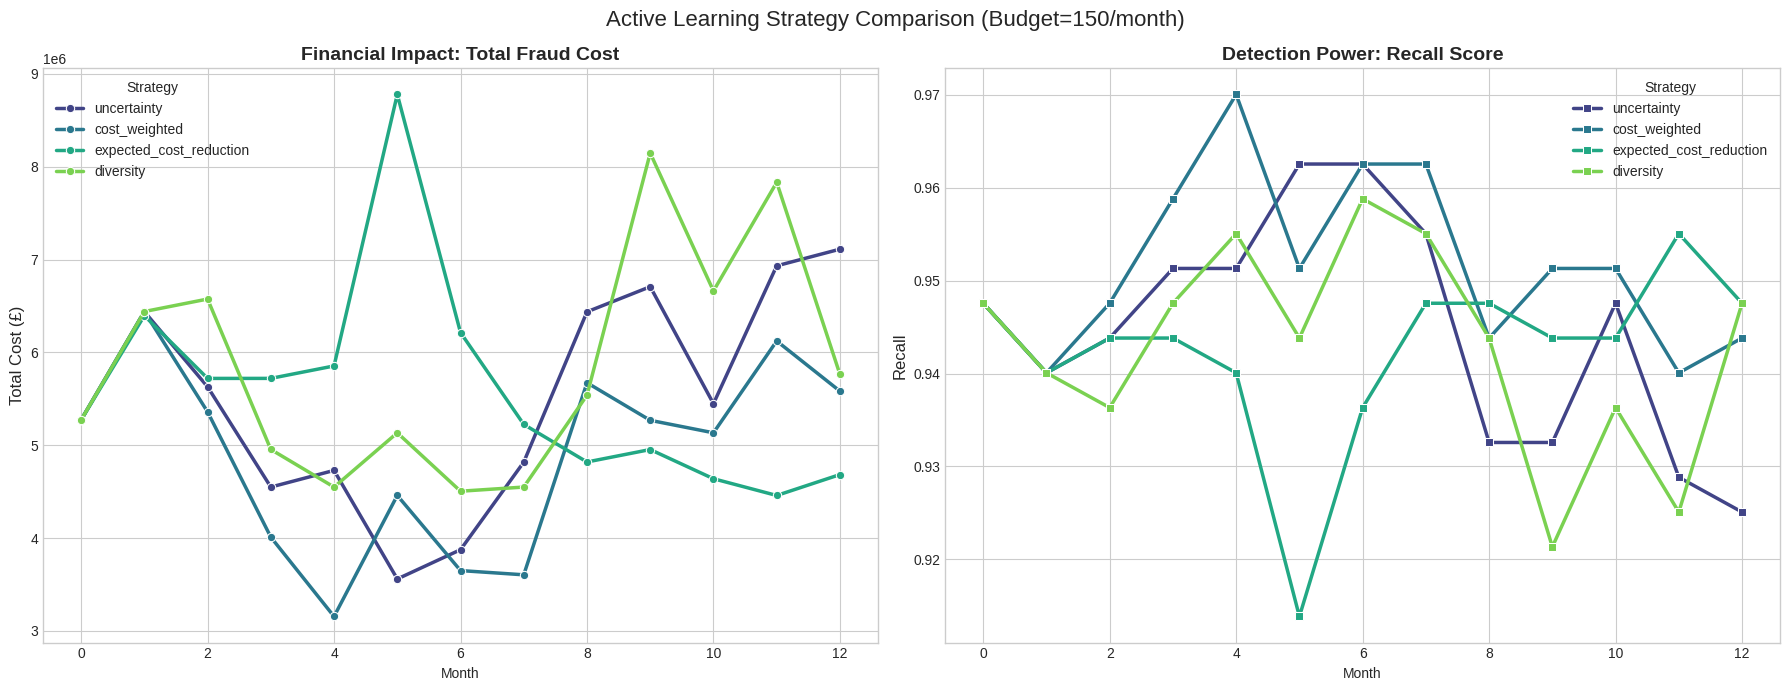


Final Cost Comparison (Month 6):
  cost_weighted            : £3,649,100 (Saved: £1,622,800)
  uncertainty              : £3,873,900 (Saved: £1,398,000)
  diversity                : £4,504,100 (Saved: £767,800)
  expected_cost_reduction  : £6,213,500 (Saved: £-941,600)


In [ ]:
# =============================================================================
# 1. SETUP & DATA LOADING
# =============================================================================
import zipfile
import pandas as pd
import numpy as np
import os
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler
from xgboost import XGBClassifier
from sklearn.cluster import MiniBatchKMeans
from sklearn.metrics import pairwise_distances_argmin_min
import warnings

warnings.filterwarnings('ignore')

# ---- PATHS ----
ZIP_PATH = "/content/data_5L_new.zip"
EXTRACT_DIR = "/content/extracted_zip"

# ---- UNZIP & LOAD ----
if not os.path.exists(EXTRACT_DIR):
    with zipfile.ZipFile(ZIP_PATH, 'r') as z:
        z.extractall(EXTRACT_DIR)

csv_file = None
for file in os.listdir(EXTRACT_DIR):
    if file.endswith(".csv"):
        csv_file = os.path.join(EXTRACT_DIR, file)
        break

if csv_file is None:
    raise FileNotFoundError("No CSV file found inside the ZIP.")

print("Loading dataset...")
df = pd.read_csv(csv_file)
print(f"Data loaded: {df.shape}")

# =============================================================================
# 2. FRAUD RULES & ANALYSIS
# =============================================================================

def analyze_fraud_rules(df):
    """
    Applies rules individually to track counts, then returns the combined flag.
    """
    print(f"\n{'='*20} FRAUD RULE BREAKDOWN {'='*20}")

    # Pre-calculations
    claim_ratio = df['sum_insured'] / (df['premium_with_tax'] + 1)
    coverage_ratio = df['sum_insured'] / (df['property_market_value'] + 1)

    # Define Rules Dictionary
    rules = {
        "1. High Claim Ratio & No Prev Ins": (claim_ratio > 1500) & (df['previous_insurance_buildings'] == 0) & (df['no_of_claims_5yr'] > 0),
        "2. Accidental Dmg & Unoccupied": (df['accidental_damage_premium'] > 0) & (df['unoccupied_days'] >= 30) & (df['no_of_claims_5yr'] > 0),
        "3. Frequent Claims (3+)": (df['no_of_claims_5yr'] >= 3),
        "4. Business Use & Unoccupied": (df['unoccupied_days'] >= 30) & (df['business_use'] == 'Y') & (df['no_of_claims_5yr'] > 0),
        # "5. Over-insured (>80% Market Val)": (coverage_ratio > 0.8) & (df['no_of_claims_5yr'] > 0),
        # "6. High Add. Coverage (>15k)": (df['additional_coverage_amount'] >= 15000) & (df['no_of_claims_5yr'] > 0),
        # "7. Poor Payment Behavior": (df['premium_payment_behaviour'] < 70) & (df['no_of_claims_5yr'] >= 2),
        # "8. Short Term Letting": (df['short_term_letting'] == 1) & (df['no_of_claims_5yr'] >= 2)
    }

    combined_flags = pd.Series(False, index=df.index)

    # Print counts for each rule
    for name, mask in rules.items():
        count = mask.sum()
        print(f"{name.ljust(45)}: {count:5d} flagged")
        combined_flags |= mask

    print(f"{'-'*60}")
    print(f"{'Total Unique Flagged Transactions'.ljust(45)}: {combined_flags.sum():5d} flagged")
    print(f"{'='*60}\n")

    return combined_flags

def prepare_features(df, categorical_cols=None):
    if categorical_cols is None:
        categorical_cols = ['cust_occupation', 'owner_details', 'property_type',
                            'construction_material', 'roof_material', 'urban_rural', 'policy_product', 'business_use']
    df_encoded = pd.get_dummies(df, columns=categorical_cols, drop_first=True)
    exclude_cols = ['fraud_label', 'fraud_probability', 'policy_no', 'unoccupied_reason']
    feature_cols = [col for col in df_encoded.columns if col not in exclude_cols]
    return df_encoded[feature_cols]

def calculate_costs(sum_insured, y_true, y_pred):
    costs = np.zeros(len(y_true))
    fn_mask = (y_true == 1) & (y_pred == 0)
    fp_mask = (y_true == 0) & (y_pred == 1)
    costs[fn_mask] = sum_insured[fn_mask] * 0.90  # FN Cost: Payout
    costs[fp_mask] = 100  # FP Cost: Investigation fee
    return costs

def evaluate_cost_sensitive(y_true, y_pred, sum_insured):
    costs = calculate_costs(sum_insured, y_true, y_pred)
    tp = np.sum((y_true == 1) & (y_pred == 1))
    fn_count = np.sum((y_true == 1) & (y_pred == 0))
    recall = tp / (tp + fn_count) if (tp + fn_count) > 0 else 0
    return {'total_cost': np.sum(costs), 'recall': recall}

def find_optimal_threshold(model, X, y, sum_insured):
    proba = model.predict_proba(X)[:, 1]
    thresholds = np.linspace(0.1, 0.9, 50)
    best_cost = float('inf')
    best_thresh = 0.5
    for thresh in thresholds:
        y_pred = (proba >= thresh).astype(int)
        cost = np.sum(calculate_costs(sum_insured, y, y_pred))
        if cost < best_cost:
            best_cost = cost
            best_thresh = thresh
    return best_thresh

# =============================================================================
# 3. ADVANCED ACTIVE LEARNING CLASS
# =============================================================================

class ActiveLearningAgent:
    def __init__(self):
        self.model = XGBClassifier(
            n_estimators=100, max_depth=6, learning_rate=0.1,
            scale_pos_weight=5, random_state=42, eval_metric='logloss', n_jobs=-1
        )
        self.scaler = StandardScaler()
        self.threshold = 0.5
        self.labeled_data = {'X': None, 'y': None, 'sum_insured': None}
        self.feature_names = None

    def _align(self, df_input):
        X_feat = prepare_features(df_input.copy())
        for col in self.feature_names:
            if col not in X_feat.columns: X_feat[col] = 0
        return X_feat[self.feature_names].values

    def initial_train(self, df_universe, flagged_indices):
        investigated = df_universe.loc[flagged_indices]
        X_df = prepare_features(investigated.copy())
        self.feature_names = X_df.columns.tolist()

        X = X_df.values
        y = investigated['fraud_label'].values
        s = investigated['sum_insured'].values

        X_scaled = self.scaler.fit_transform(X)
        self.labeled_data = {'X': X_scaled, 'y': y, 'sum_insured': s}

        self.model.fit(X_scaled, y)
        self.threshold = find_optimal_threshold(self.model, X_scaled, y, s)

    def query(self, df_pool, budget, strategy):
        X_pool = self._align(df_pool)
        X_scaled = self.scaler.transform(X_pool)
        y_proba = self.model.predict_proba(X_scaled)[:, 1]
        sum_insured = df_pool['sum_insured'].values
        indices = df_pool.index.tolist()

        if strategy == 'uncertainty':
            scores = np.abs(y_proba - 0.5)
            selected_idx = [indices[i] for i in np.argsort(scores)[:budget]]

        elif strategy == 'cost_weighted':
            uncertainty = 0.5 - np.abs(y_proba - 0.5)
            norm_cost = sum_insured / (np.max(sum_insured) + 1)
            scores = uncertainty * norm_cost
            selected_idx = [indices[i] for i in np.argsort(scores)[::-1][:budget]]

        elif strategy == 'expected_cost_reduction':
            risk_if_0 = y_proba * (sum_insured * 0.90)
            risk_if_1 = (1 - y_proba) * 100
            current_risk = np.where(y_proba < self.threshold, risk_if_0, risk_if_1)
            selected_idx = [indices[i] for i in np.argsort(current_risk)[::-1][:budget]]

        elif strategy == 'diversity':
            # --- UPDATED DIVERSITY STRATEGY ---

            # 1. Clustering based on FEATURES (to find groups)
            # Use more clusters than budget to ensure granular groups
            n_clusters = max(5, budget // 2)
            kmeans = MiniBatchKMeans(n_clusters=n_clusters, random_state=42, batch_size=256)
            cluster_labels = kmeans.fit_predict(X_scaled)

            # 2. Calculate Distance to Centroids (Boundary detection)
            # transform() returns distance to all centers; we take min (dist to own center)
            dists = kmeans.transform(X_scaled)
            dist_to_center = np.min(dists, axis=1)

            # 3. Organize Data
            pool_data = pd.DataFrame({
                'idx': indices,
                'cluster': cluster_labels,
                'prob': y_proba,
                'dist': dist_to_center
            })

            # 4. Filter Noise: Remove clusters with fewer than MIN_POINTS
            MIN_POINTS = 5
            cluster_counts = pool_data['cluster'].value_counts()
            valid_clusters = cluster_counts[cluster_counts >= MIN_POINTS].index
            pool_data = pool_data[pool_data['cluster'].isin(valid_clusters)]

            # 5. Calculate Selection Score
            # Score = Uncertainty (Primary) + Boundary Distance (Secondary)
            # Uncertainty: Closer to 0.5 is better. (1 - |2*prob - 1|) gives 1 at prob=0.5
            uncertainty_score = 1 - np.abs(2 * pool_data['prob'] - 1)

            # Normalize distance for combination
            dist_score = (pool_data['dist'] - pool_data['dist'].min()) / (pool_data['dist'].max() - pool_data['dist'].min() + 1e-6)

            # Weighted Score: We prefer Uncertain points, but if equal, prefer Boundary points
            pool_data['score'] = uncertainty_score + (0.5 * dist_score)

            # 6. Round-Robin Selection
            selected_idx = []

            # Sort within clusters by score
            groups = pool_data.groupby('cluster')
            sorted_groups = {k: v.sort_values('score', ascending=False) for k, v in groups}

            # Cycle through clusters picking top candidate
            active_clusters = list(sorted_groups.keys())
            while len(selected_idx) < budget and active_clusters:
                for c_id in list(active_clusters): # Iterate copy to allow removal
                    if len(selected_idx) >= budget:
                        break

                    if not sorted_groups[c_id].empty:
                        # Pick top point
                        top_point = sorted_groups[c_id].iloc[0]
                        selected_idx.append(top_point['idx'])
                        # Remove picked point
                        sorted_groups[c_id] = sorted_groups[c_id].iloc[1:]
                    else:
                        active_clusters.remove(c_id)

        return selected_idx

    def retrain(self, df_universe, new_indices):
        new_data = df_universe.loc[new_indices]
        X_new = self.scaler.transform(self._align(new_data))
        y_new = new_data['fraud_label'].values
        s_new = new_data['sum_insured'].values

        self.labeled_data['X'] = np.vstack([self.labeled_data['X'], X_new])
        self.labeled_data['y'] = np.concatenate([self.labeled_data['y'], y_new])
        self.labeled_data['sum_insured'] = np.concatenate([self.labeled_data['sum_insured'], s_new])

        self.model.fit(self.labeled_data['X'], self.labeled_data['y'])
        self.threshold = find_optimal_threshold(
            self.model, self.labeled_data['X'], self.labeled_data['y'], self.labeled_data['sum_insured']
        )

    def evaluate(self, df_test):
        X_test = self.scaler.transform(self._align(df_test))
        y_test = df_test['fraud_label'].values
        s_test = df_test['sum_insured'].values
        y_pred = (self.model.predict_proba(X_test)[:, 1] >= self.threshold).astype(int)
        return evaluate_cost_sensitive(y_test, y_pred, s_test)

# =============================================================================
# 4. COMPARATIVE SIMULATION LOOP
# =============================================================================

def run_comparison(df, strategies, n_months=6, monthly_vol=1000, budget=200):
    # 1. Common Pre-processing & Fraud Analysis
    initial_pool = df.sample(n=10000, random_state=42)

    # --- CHANGED: Use new analyze function here ---
    flags = analyze_fraud_rules(initial_pool)
    flagged_idx = initial_pool[flags].index

    # Common Test Set
    avail_after_init = df.drop(index=initial_pool.index)
    test_set = avail_after_init.sample(n=5000, random_state=999)

    # Track used indices for the simulation stream
    base_used_indices = set(initial_pool.index) | set(test_set.index)

    all_results = []

    print(f"{'='*80}")
    print(f"STARTING COMPARISON OF {len(strategies)} STRATEGIES")
    print(f"{'='*80}")

    for strat in strategies:
        print(f"\n>> Running Strategy: {strat.upper()}")

        # Reset Agent
        agent = ActiveLearningAgent()
        agent.initial_train(df, flagged_idx)

        # Local copy of used indices for this run
        current_used_indices = base_used_indices.copy()

        # Baseline
        base_metrics = agent.evaluate(test_set)
        all_results.append({
            'Strategy': strat, 'Month': 0,
            'Cost': base_metrics['total_cost'], 'Recall': base_metrics['recall']
        })

        for month in range(1, n_months + 1):
            # Ensure every strategy gets the SAME batch of new customers
            available = df.drop(index=current_used_indices)
            if len(available) < monthly_vol: break

            new_batch = available.sample(n=monthly_vol, random_state=month)
            current_used_indices.update(new_batch.index)

            query_idx = agent.query(new_batch, budget, strat)
            agent.retrain(df, query_idx)

            metrics = agent.evaluate(test_set)
            all_results.append({
                'Strategy': strat, 'Month': month,
                'Cost': metrics['total_cost'], 'Recall': metrics['recall']
            })

    return pd.DataFrame(all_results)

# =============================================================================
# 5. EXECUTE & VISUALIZE
# =============================================================================

STRATEGIES_TO_TEST = [
    'uncertainty',
    'cost_weighted',
    'expected_cost_reduction',
    'diversity'
]

# Run Simulation
df_results = run_comparison(
    df,
    strategies=STRATEGIES_TO_TEST,
    n_months=12,
    monthly_vol=1000,
    budget=150
)

# ---- PLOTTING ----
plt.style.use('seaborn-v0_8-whitegrid')
fig, axes = plt.subplots(1, 2, figsize=(18, 7))

# 1. Total Cost
sns.lineplot(data=df_results, x='Month', y='Cost', hue='Strategy',
             marker='o', linewidth=2.5, ax=axes[0], palette='viridis')
axes[0].set_title('Financial Impact: Total Fraud Cost', fontsize=14, fontweight='bold')
axes[0].set_ylabel('Total Cost (£)', fontsize=12)

# 2. Recall
sns.lineplot(data=df_results, x='Month', y='Recall', hue='Strategy',
             marker='s', linewidth=2.5, ax=axes[1], palette='viridis')
axes[1].set_title('Detection Power: Recall Score', fontsize=14, fontweight='bold')
axes[1].set_ylabel('Recall', fontsize=12)

plt.suptitle(f'Active Learning Strategy Comparison (Budget={150}/month)', fontsize=16)
plt.tight_layout()
plt.show()

# ---- SUMMARY TABLE ----
pivot_cost = df_results.pivot(index='Strategy', columns='Month', values='Cost')
print("\nFinal Cost Comparison (Month 6):")
final_costs = pivot_cost[6].sort_values()
baseline_cost = pivot_cost[0].mean()
for strat, cost in final_costs.items():
    saving = baseline_cost - cost
    print(f"  {strat.ljust(25)}: £{cost:,.0f} (Saved: £{saving:,.0f})")

Test set fixed: (800, 50)
Remaining pool: (499200, 50)

==================== FRAUD RULE BREAKDOWN ====================
1. High Claim Ratio & No Prev Ins            : 14350 flagged
2. Accidental Dmg & Unoccupied               :  8893 flagged
3. Frequent Claims (3+)                      : 24133 flagged
4. Business Use & Unoccupied                 :   764 flagged
------------------------------------------------------------
Total Unique Flagged Transactions            : 43143 flagged

Initial AL seed size: (2000, 50)

Running AL Strategy: UNCERTAINTY

Running AL Strategy: COST_WEIGHTED

Running AL Strategy: EXPECTED_COST_REDUCTION

Running AL Strategy: DIVERSITY


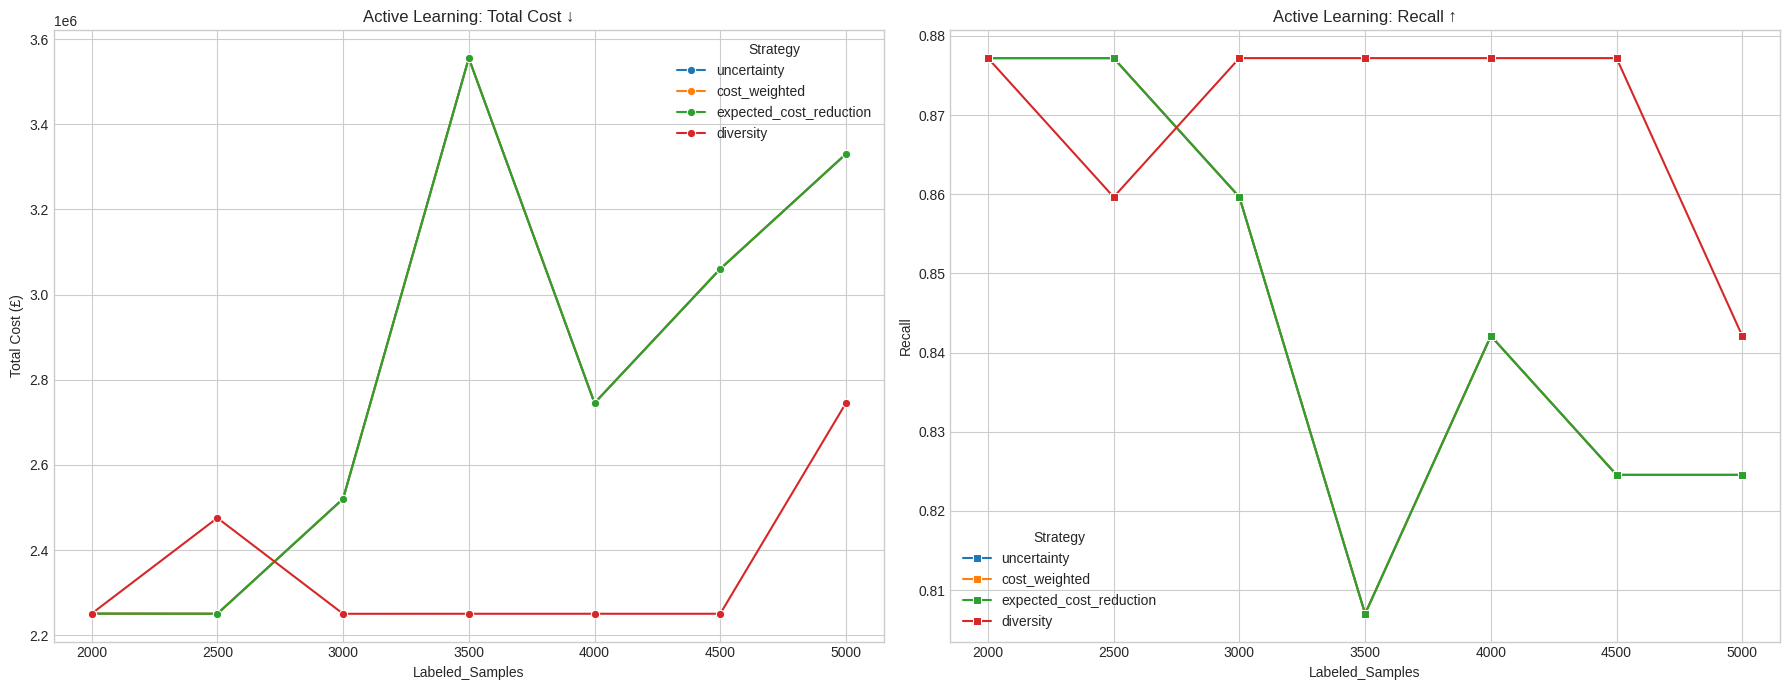

In [ ]:
# =============================================================================
# ACTIVE LEARNING MODULE (STRICTLY AL ONLY) — FIXED
# =============================================================================

# -------------------------
# TUNABLE PARAMETERS
# -------------------------
INITIAL_FRAUD_SEED = 2000
AL_BATCH_SIZE = 500
TOTAL_AL_BUDGET = 5000
TEST_SIZE = 800
MAX_ITER = (TOTAL_AL_BUDGET - INITIAL_FRAUD_SEED) // AL_BATCH_SIZE

STRATEGIES = [
    'uncertainty',
    'cost_weighted',
    'expected_cost_reduction',
    'diversity'
]

# =============================================================================
# 1. FIX TEST SET FIRST
# =============================================================================
df = df.sample(frac=1, random_state=42).reset_index(drop=True)

test_df = df.iloc[:TEST_SIZE].copy()
remaining_df = df.iloc[TEST_SIZE:].copy()

print(f"Test set fixed: {test_df.shape}")
print(f"Remaining pool: {remaining_df.shape}")

# =============================================================================
# 2. INITIAL TRAINING DATA VIA FRAUD RULES (TOP ROWS)
# =============================================================================
fraud_flags = analyze_fraud_rules(remaining_df)

flagged_idx = []
for idx, flag in fraud_flags.items():
    if flag:
        flagged_idx.append(idx)
    if len(flagged_idx) >= INITIAL_FRAUD_SEED:
        break

initial_train_df = remaining_df.loc[flagged_idx].copy()

# IMPORTANT FIX: only track indices from remaining_df
used_indices = set(flagged_idx)

print(f"Initial AL seed size: {initial_train_df.shape}")

# =============================================================================
# 3. ACTIVE LEARNING LOOP
# =============================================================================

def run_active_learning(strategy):
    agent = ActiveLearningAgent()
    agent.initial_train(remaining_df, flagged_idx)

    history = []

    # Baseline evaluation
    base_metrics = agent.evaluate(test_df)
    history.append({
        'Strategy': strategy,
        'Iteration': 0,
        'Labeled_Samples': INITIAL_FRAUD_SEED,
        'Cost': base_metrics['total_cost'],
        'Recall': base_metrics['recall']
    })

    labeled_count = INITIAL_FRAUD_SEED
    current_used = set(flagged_idx)  # ONLY remaining_df indices

    for it in range(1, MAX_ITER + 1):

        # SAFE DROP
        available_pool = remaining_df.drop(
            index=current_used,
            errors='ignore'
        )

        if len(available_pool) < AL_BATCH_SIZE:
            break

        pool_batch = available_pool.iloc[:AL_BATCH_SIZE].copy()
        current_used.update(pool_batch.index)

        queried_idx = agent.query(pool_batch, AL_BATCH_SIZE, strategy)
        agent.retrain(remaining_df, queried_idx)

        labeled_count += AL_BATCH_SIZE

        metrics = agent.evaluate(test_df)
        history.append({
            'Strategy': strategy,
            'Iteration': it,
            'Labeled_Samples': labeled_count,
            'Cost': metrics['total_cost'],
            'Recall': metrics['recall']
        })

    return pd.DataFrame(history)

# =============================================================================
# 4. RUN ALL STRATEGIES
# =============================================================================
all_results = []

for strat in STRATEGIES:
    print(f"\nRunning AL Strategy: {strat.upper()}")
    res = run_active_learning(strat)
    all_results.append(res)

df_al_results = pd.concat(all_results, ignore_index=True)

# =============================================================================
# 5. VISUALIZATION
# =============================================================================
plt.figure(figsize=(18, 7))

plt.subplot(1, 2, 1)
sns.lineplot(
    data=df_al_results,
    x='Labeled_Samples',
    y='Cost',
    hue='Strategy',
    marker='o'
)
plt.title("Active Learning: Total Cost ↓")
plt.ylabel("Total Cost (£)")

plt.subplot(1, 2, 2)
sns.lineplot(
    data=df_al_results,
    x='Labeled_Samples',
    y='Recall',
    hue='Strategy',
    marker='s'
)
plt.title("Active Learning: Recall ↑")
plt.ylabel("Recall")

plt.tight_layout()
plt.show()
